## Cell 1 — Library Imports & Global Configuration

In [19]:
import numpy as np
import pandas as pd
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from scipy.fft import fft, fftfreq

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split, GridSearchCV, cross_validate)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve, average_precision_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import sklearn

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imblearn not found. Install with: pip install imbalanced-learn')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# GLOBAL STYLING
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {'Control': '#2ecc71', 'Cancer': '#e74c3c', 'Benign': '#e67e22'}
BINARY_PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

# CONSTANTS
RANDOM_STATE = 42
N_FOLDS = 5
SAMPLING_RATE = 100
MEASUREMENT_DURATION = 60
N_POINTS = SAMPLING_RATE * MEASUREMENT_DURATION
N_SENSORS = 22
N_MOS = 10
N_EC = 8
N_PID = 1
N_QCM = 2

print('Libraries loaded')
print(f'Constants initialized: {N_FOLDS} folds, {N_POINTS} points')
print(f'scikit-learn: {sklearn.__version__}, imbalanced-learn: {"available" if SMOTE_AVAILABLE else "not available"}')
print(f'numpy: {np.__version__}, pandas: {pd.__version__}')


Libraries loaded
Constants initialized: 5 folds, 6000 points
scikit-learn: 1.8.0, imbalanced-learn: available
numpy: 1.26.4, pandas: 3.0.2


## Cell 2 — Raw Sensor Calibration Functions

In [20]:
# ══════════════════════════════════════════════════════
# 2A. MOS SENSORS — Power-Law Model
# Rs/R0 = a · C^(-b)  →  C = (Rs/R0 / a)^(-1/b)

def mos_model(C, a, b):
    return a * np.power(C, -b)

def calibrate_mos(known_ppb, measured_Rs_R0):
    popt, pcov = curve_fit(
        mos_model, known_ppb, measured_Rs_R0,
        p0=[1.0, 0.3], bounds=([0, 0], [np.inf, np.inf]),
        maxfev=10000
    )
    a, b = popt
    perr = np.sqrt(np.diag(pcov))
    print(f'  MOS fit → a={a:.4f}±{perr[0]:.4f}, b={b:.4f}±{perr[1]:.4f}')
    return {'a': a, 'b': b, 'type': 'MOS'}

def mos_to_ppb(Rs_R0, params):
    a, b = params['a'], params['b']
    Rs_R0_clamped = np.clip(Rs_R0, 1e-6, None)
    return np.power(Rs_R0_clamped / a, -1.0 / b)

# ══════════════════════════════════════════════════════
# 2B. EC SENSORS — Linear Model
#     C (ppb) = (I - I_zero) / sensitivity

def calibrate_ec(known_ppb, measured_nA):
    lr = LinearRegression().fit(
        np.array(known_ppb).reshape(-1, 1),
        np.array(measured_nA)
    )
    sensitivity = lr.coef_[0]
    I_zero = lr.intercept_
    print(f'  EC fit  → sensitivity={sensitivity:.4f} nA/ppb, I_zero={I_zero:.2f} nA')
    return {'sensitivity': sensitivity, 'I_zero': I_zero, 'type': 'EC'}

def ec_to_ppb(I_nA, params):
    conc = (np.array(I_nA) - params['I_zero']) / params['sensitivity']
    return np.clip(conc, 0, None)

# ══════════════════════════════════════════════════════
# 2C. PID SENSOR — Linear + Response Factor Correction
#     C (ppb) = V_output / (RF_compound × Sensitivity_ref)

PID_RESPONSE_FACTORS = {
    'benzene':      0.53,
    'toluene':      0.54,
    'ethylbenzene': 0.52,
    'xylene':       0.52,
    'styrene':      0.40,
    'isobutylene':  1.00,
    'generic_btex': 0.52,
}

def calibrate_pid(known_ppb_isobutylene, measured_V):
    lr = LinearRegression().fit(
        np.array(known_ppb_isobutylene).reshape(-1, 1),
        np.array(measured_V)
    )
    sensitivity = lr.coef_[0]
    V_zero = lr.intercept_
    print(f'  PID fit → sensitivity={sensitivity:.6f} V/ppb, V_zero={V_zero:.4f} V')
    return {'sensitivity': sensitivity, 'V_zero': V_zero, 'type': 'PID'}

def pid_to_ppb(V_raw, params, compound='generic_btex'):
    RF = PID_RESPONSE_FACTORS.get(compound, 0.52)
    V_corrected = np.array(V_raw) - params['V_zero']
    conc = V_corrected / (RF * params['sensitivity'])
    return np.clip(conc, 0, None)

# ══════════════════════════════════════════════════════
# 2D. QCM SENSORS — Sauerbrey Equation
#     Δm = -Δf · A·√(ρq·μq) / (2f₀²)
#     C (ppb) via ideal gas law

QCM_CONSTANTS = {
    'f0':      10e6,     # Hz, resonant frequency
    'A':       1.54e-5,  # m², electrode area
    'rho_q':   2650,     # kg/m³, quartz density
    'mu_q':    2.947e10, # Pa, quartz shear modulus
    'V_cell':  50e-6,    # m³, sensor cell volume
    'T_K':     310,      # K, temperature (37°C)
    'P_Pa':    101325,   # Pa, atmospheric pressure
    'R_gas':   8.314,    # J/(mol·K)
}

VOC_MW = {
    'acetone':      0.05808,
    'isoprene':     0.06811,
    'ethanol':      0.04607,
    'pentane':      0.07215,
    'generic':      0.06000,
}

def qcm_to_ppb(delta_f, compound='generic', constants=None):
    if constants is None:
        constants = QCM_CONSTANTS
    
    f0    = constants['f0']
    A     = constants['A']
    rho_q = constants['rho_q']
    mu_q  = constants['mu_q']
    V_cell = constants['V_cell']
    T_K   = constants['T_K']
    P_Pa  = constants['P_Pa']
    R_gas = constants['R_gas']
    MW    = VOC_MW.get(compound, VOC_MW['generic'])
    
    # Sauerbrey: Mass-Change
    delta_m = (-np.array(delta_f) * A * np.sqrt(rho_q * mu_q)) / (2 * f0**2)
    delta_m = np.clip(delta_m, 0, None)  # mass can only increase on adsorption
    
    # Moles Adsorbed
    moles = delta_m / MW
    
    # Gas-phase concentration (mol/m³) → molar fraction → ppb
    # Using ideal gas: n/V = P/(RT) for total gas
    total_molar_density = P_Pa / (R_gas * T_K)  # mol/m³
    molar_fraction = (moles / V_cell) / total_molar_density
    ppb = molar_fraction * 1e9
    
    return ppb

# ══════════════════════════════════════════════════════
# 2E. Temperature & Humidity Compensation

def compensate_TRH(C_raw, T_C, RH_pct,
                    T_ref=25.0, RH_ref=50.0,
                    alpha_T=-0.008, alpha_RH=-0.003):
    delta_T  = np.array(T_C) - T_ref
    delta_RH = np.array(RH_pct) - RH_ref
    correction_factor = 1 + alpha_T * delta_T + alpha_RH * delta_RH
    correction_factor = np.clip(correction_factor, 0.5, 1.5)  # safety bounds
    return np.array(C_raw) / correction_factor

print('Calibration functions:')
print('   ├─ MOS  : power-law model (Rs/R0 = a·C^-b)')
print('   ├─ EC   : linear model (I = S·C + I_zero)')
print('   ├─ PID  : linear + response factor correction')
print('   ├─ QCM  : Sauerbrey equation + ideal gas law')
print('   └─ T/RH : linear compensation surface')


Calibration functions:
   ├─ MOS  : power-law model (Rs/R0 = a·C^-b)
   ├─ EC   : linear model (I = S·C + I_zero)
   ├─ PID  : linear + response factor correction
   ├─ QCM  : Sauerbrey equation + ideal gas law
   └─ T/RH : linear compensation surface


## Cell 3 — Simulated Calibration Data & Curve Fitting Demo

───────────────────────────────────────────────────────
MOS Sensor Calibration (WO3 / Acetone)
  MOS fit → a=1.0082±0.0047, b=0.3500±0.0024

EC Sensor Calibration (Formaldehyde)
  EC fit  → sensitivity=0.0849 nA/ppb, I_zero=12.32 nA

PID Sensor Calibration (Isobutylene Reference)
  PID fit → sensitivity=0.004201 V/ppb, V_zero=0.0088 V

QCM Sensor (Sauerbrey verification)
  Δf =    -5 Hz  →  29.80 ppb acetone
  Δf =   -25 Hz  →  149.01 ppb acetone
  Δf =   -50 Hz  →  298.01 ppb acetone
  Δf =  -100 Hz  →  596.02 ppb acetone
  Δf =  -250 Hz  →  1490.05 ppb acetone


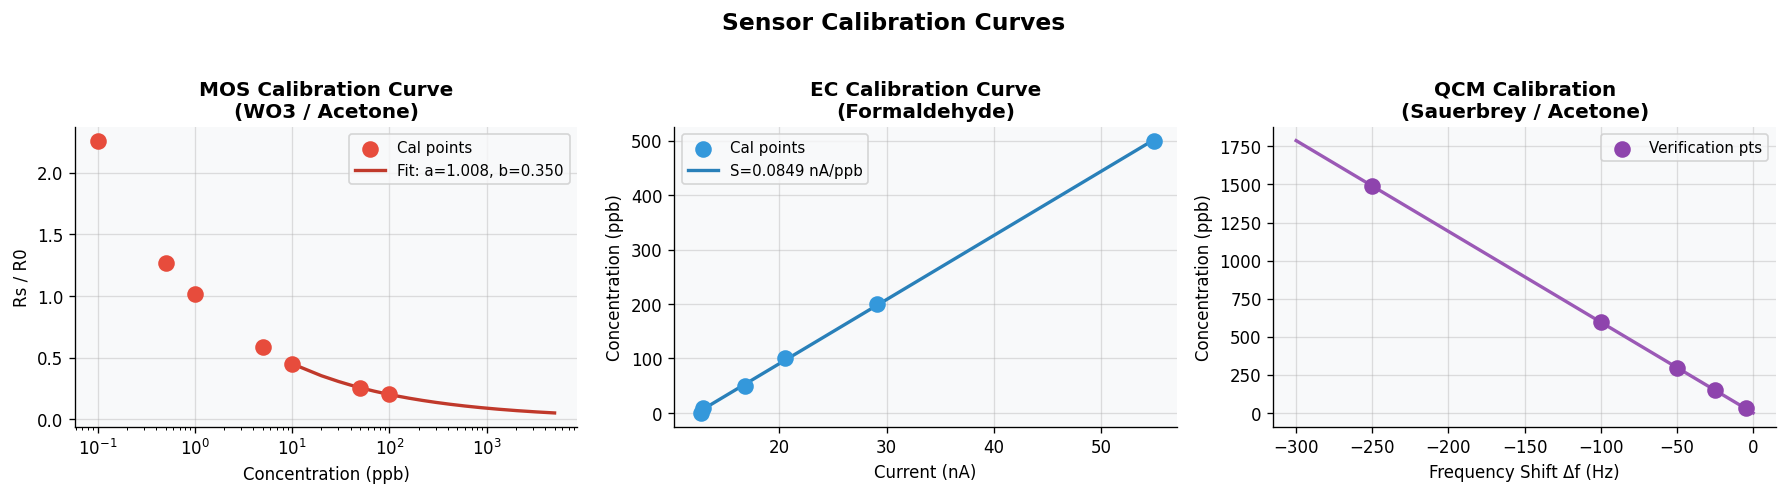


 Calibration parameters fitted and validated


In [21]:
import numpy as np

np.random.seed(RANDOM_STATE)

# 3A. MOS Calibration Example
print('─' * 55)
print('MOS Sensor Calibration (WO3 / Acetone)')
mos_cal_ppb   = np.array([0.1, 0.5, 1, 5, 10, 50, 100])
true_a, true_b = 1.0, 0.35
mos_cal_Rs_R0 = mos_model(mos_cal_ppb, true_a, true_b) * (1 + 0.02 * np.random.randn(len(mos_cal_ppb)))
mos_params = calibrate_mos(mos_cal_ppb, mos_cal_Rs_R0)

# 3B. EC Calibration Example (e.g., formaldehyde sensor)
print('\nEC Sensor Calibration (Formaldehyde)')
ec_cal_ppb = np.array([0, 10, 50, 100, 200, 500])
ec_cal_nA  = 0.085 * ec_cal_ppb + 12.3 + 0.5 * np.random.randn(len(ec_cal_ppb))
ec_params  = calibrate_ec(ec_cal_ppb, ec_cal_nA)

# 3C. PID Calibration Example (isobutylene reference)
print('\nPID Sensor Calibration (Isobutylene Reference)')
pid_cal_ppb = np.array([0, 10, 50, 100, 500, 1000])
pid_cal_V   = 0.0042 * pid_cal_ppb + 0.01 + 0.001 * np.random.randn(len(pid_cal_ppb))
pid_params  = calibrate_pid(pid_cal_ppb, pid_cal_V)

# 3D. QCM Calibration — verify conversion
print('\nQCM Sensor (Sauerbrey verification)')
test_delta_f = np.array([-5, -25, -50, -100, -250])
qcm_ppb_out  = qcm_to_ppb(test_delta_f, compound='acetone')
for df_hz, c in zip(test_delta_f, qcm_ppb_out):
    print(f'  Δf = {df_hz:5.0f} Hz  →  {c:.2f} ppb acetone')

# 3E. Plot calibration curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MOS
C_range = np.linspace(10, 5000, 500)
axes[0].scatter(mos_cal_ppb, mos_cal_Rs_R0, color='#e74c3c', s=80, zorder=5, label='Cal points')
axes[0].plot(C_range, mos_model(C_range, mos_params['a'], mos_params['b']),
             color='#c0392b', linewidth=2, label=f"Fit: a={mos_params['a']:.3f}, b={mos_params['b']:.3f}")
axes[0].set_xlabel('Concentration (ppb)')
axes[0].set_ylabel('Rs / R0')
axes[0].set_title('MOS Calibration Curve\n(WO3 / Acetone)', fontweight='bold')
axes[0].set_xscale('log')
axes[0].legend(fontsize=9)

# EC
I_range = np.linspace(12, 60, 200)
axes[1].scatter(ec_cal_nA, ec_cal_ppb, color='#3498db', s=80, zorder=5, label='Cal points')
axes[1].plot(ec_params['sensitivity'] * np.array(ec_cal_ppb) + ec_params['I_zero'],
             ec_cal_ppb, color='#2980b9', linewidth=2,
             label=f"S={ec_params['sensitivity']:.4f} nA/ppb")
axes[1].set_xlabel('Current (nA)')
axes[1].set_ylabel('Concentration (ppb)')
axes[1].set_title('EC Calibration Curve\n(Formaldehyde)', fontweight='bold')
axes[1].legend(fontsize=9)

# QCM
df_range = np.linspace(-300, 0, 200)
axes[2].plot(df_range, qcm_to_ppb(df_range, compound='acetone'),
             color='#9b59b6', linewidth=2)
axes[2].scatter(test_delta_f, qcm_ppb_out, color='#8e44ad', s=80, zorder=5, label='Verification pts')
axes[2].set_xlabel('Frequency Shift Δf (Hz)')
axes[2].set_ylabel('Concentration (ppb)')
axes[2].set_title('QCM Calibration\n(Sauerbrey / Acetone)', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Sensor Calibration Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Calibration parameters fitted and validated')

## Cell 4 — Apply Calibration: Raw Signals to Ppb Concentrations

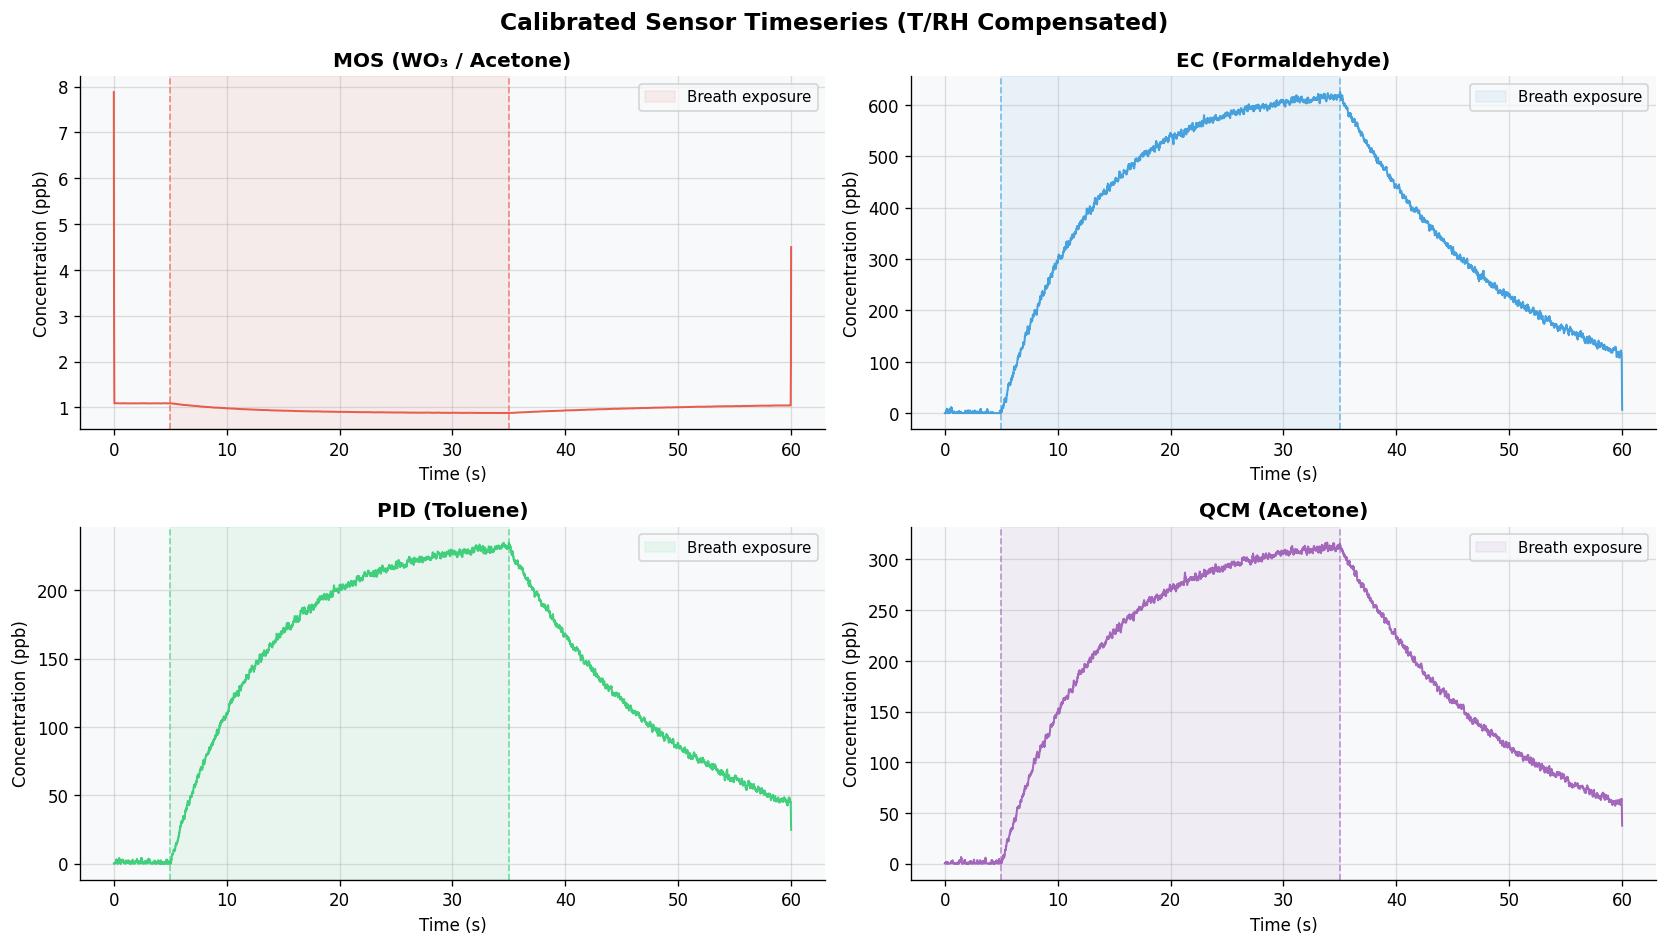

Raw signals converted to T/RH-compensated ppb concentrations


In [22]:
# In real deployment: replace simulate_* functions with your
# actual STM32H7 ADC data acquisition output.

def simulate_breath_timeseries(sensor_type, baseline, peak_ppb, 
                                 n_points=N_POINTS, t_exposure=30,
                                 noise_level=0.02):
    """
    Simulate a realistic sensor response curve:
    - Phase 1: Zero baseline (0–5s)
    - Phase 2: Breath exposure with exponential rise (5–35s)
    - Phase 3: Recovery with exponential decay (35–60s)
    
    Returns: time array (s), raw signal array
    """
    t = np.linspace(0, MEASUREMENT_DURATION, n_points)
    signal = np.zeros(n_points)
    
    t_start, t_end = 5, 35  # exposure window
    tau_rise, tau_fall = 8, 15  # time constants (seconds)
    
    for i, ti in enumerate(t):
        if ti < t_start:
            signal[i] = baseline
        elif ti < t_end:
            rise = 1 - np.exp(-(ti - t_start) / tau_rise)
            signal[i] = baseline + peak_ppb * rise
        else:
            peak_reached = baseline + peak_ppb * (1 - np.exp(-(t_end - t_start) / tau_rise))
            signal[i] = baseline + (peak_reached - baseline) * np.exp(-(ti - t_end) / tau_fall)
    
    # Add realistic noise
    signal += noise_level * peak_ppb * np.random.randn(n_points)
    # Apply moving average smoothing (mimics STM32 pipeline)
    signal = np.convolve(signal, np.ones(10)/10, mode='same')
    return t, signal

# ── Generate one example measurement per sensor type ──────────────────
np.random.seed(42)
t, mos_raw_Rs   = simulate_breath_timeseries('MOS', baseline=10000, peak_ppb=800)
# Convert Rs to Rs/R0 (R0 = baseline resistance)
R0_mos = np.mean(mos_raw_Rs[:500])  # first 5s is zero-air baseline
mos_Rs_R0 = mos_raw_Rs / R0_mos
mos_ppb_ts = mos_to_ppb(mos_Rs_R0, mos_params)

_, ec_raw_nA    = simulate_breath_timeseries('EC', baseline=12.3, peak_ppb=50)
ec_ppb_ts       = ec_to_ppb(ec_raw_nA, ec_params)

_, pid_raw_V    = simulate_breath_timeseries('PID', baseline=0.01, peak_ppb=0.5)
pid_ppb_ts      = pid_to_ppb(pid_raw_V, pid_params, compound='toluene')

_, qcm_raw_df   = simulate_breath_timeseries('QCM', baseline=0, peak_ppb=-50)
qcm_ppb_ts      = qcm_to_ppb(qcm_raw_df, compound='acetone')

# ── Apply T/RH compensation ────────────────────────────────────────────
# Simulate SHT31 reading: 28°C, 65% RH (typical exhaled breath conditions)
T_measured  = 28.0
RH_measured = 65.0
mos_ppb_comp  = compensate_TRH(mos_ppb_ts, T_measured, RH_measured)
ec_ppb_comp   = compensate_TRH(ec_ppb_ts,  T_measured, RH_measured)
pid_ppb_comp  = compensate_TRH(pid_ppb_ts, T_measured, RH_measured)
qcm_ppb_comp  = compensate_TRH(qcm_ppb_ts, T_measured, RH_measured)

# ── Plot calibrated timeseries ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, ts, label, color, unit in zip(
    axes,
    [mos_ppb_comp, ec_ppb_comp, pid_ppb_comp, qcm_ppb_comp],
    ['MOS (WO₃ / Acetone)', 'EC (Formaldehyde)', 'PID (Toluene)', 'QCM (Acetone)'],
    ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'],
    ['ppb', 'ppb', 'ppb', 'ppb']
):
    ax.plot(t, ts, color=color, linewidth=1.2, alpha=0.9)
    ax.axvspan(5, 35, alpha=0.08, color=color, label='Breath exposure')
    ax.axvline(5, color=color, linestyle='--', alpha=0.6, linewidth=1)
    ax.axvline(35, color=color, linestyle='--', alpha=0.6, linewidth=1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'Concentration ({unit})')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Calibrated Sensor Timeseries (T/RH Compensated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('calibrated_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Raw signals converted to T/RH-compensated ppb concentrations')

## Cell 5 — Feature Extraction from Timeseries

In [23]:
def extract_features_from_timeseries(signal, t,
                                      t_zero_end=5.0,
                                      t_exposure_start=5.0,
                                      t_exposure_end=35.0,
                                      t_recovery_end=60.0,
                                      n_fft_coeff=5):
    """
    Extract 6 core features from a single sensor timeseries.
    
    Args:
        signal             : 1D array of calibrated ppb values (6000 points)
        t                  : time array (seconds)
        t_zero_end         : end of zero-air baseline phase (s)
        t_exposure_start   : start of breath exposure (s)
        t_exposure_end     : end of breath exposure (s)
        t_recovery_end     : end of recovery phase (s)
        n_fft_coeff        : number of FFT coefficients to extract
    
    Returns:
        dict of 6 features
    """
    dt = t[1] - t[0]
    
    # Index masks
    mask_zero     = t < t_zero_end
    mask_exposure = (t >= t_exposure_start) & (t <= t_exposure_end)
    mask_recovery = (t > t_exposure_end) & (t <= t_recovery_end)
    
    # Baseline (zero-air signal)
    baseline = np.mean(signal[mask_zero]) if mask_zero.sum() > 0 else 0.0
    
    # Delta signal (baseline-subtracted)
    delta = signal - baseline
    delta_exposure = delta[mask_exposure]
    delta_recovery = delta[mask_recovery]
    
    # ── Feature 1: Peak Response ───────────────────────────────────────
    peak_response = float(np.max(np.abs(delta_exposure))) if len(delta_exposure) > 0 else 0.0
    
    # ── Feature 2: t90 — Response time to 90% of peak ─────────────────
    t90 = 0.0
    if peak_response > 0:
        threshold_90 = 0.90 * peak_response
        t_exp = t[mask_exposure]
        above = np.where(np.abs(delta_exposure) >= threshold_90)[0]
        t90 = float(t_exp[above[0]] - t_exposure_start) if len(above) > 0 else float(t_exposure_end - t_exposure_start)
    
    # ── Feature 3: t10 — Recovery time back to 10% of peak ────────────
    t10 = 0.0
    if peak_response > 0 and len(delta_recovery) > 0:
        threshold_10 = 0.10 * peak_response
        t_rec = t[mask_recovery]
        below = np.where(np.abs(delta_recovery) <= threshold_10)[0]
        t10 = float(t_rec[below[0]] - t_exposure_end) if len(below) > 0 else float(t_recovery_end - t_exposure_end)
    
    # ── Feature 4: Slope (rate of change in rising phase) ─────────────
    slope = 0.0
    if len(delta_exposure) > 1:
        # Linear fit to first 50% of exposure window (rising phase)
        n_half = len(delta_exposure) // 2
        t_rise = t[mask_exposure][:n_half]
        d_rise = delta_exposure[:n_half]
        if len(t_rise) > 2:
            coeffs = np.polyfit(t_rise, d_rise, 1)
            slope = float(coeffs[0])
    
    # ── Feature 5: AUC — Area Under Curve (exposure window) ───────────
    auc = 0.0
    if len(delta_exposure) > 1:
        t_exp = t[mask_exposure]
        auc = float(trapezoid(np.abs(delta_exposure), t_exp))
    
    # ── Feature 6: FFT dominant frequency coefficient ──────────────────
    # Extract top n_fft_coeff magnitude coefficients from exposure window
    fft_features = []
    if len(delta_exposure) > n_fft_coeff * 2:
        fft_vals = np.abs(fft(delta_exposure))[:len(delta_exposure)//2]
        # Sort by magnitude, take top n_fft_coeff
        top_idx = np.argsort(fft_vals)[-n_fft_coeff:]
        fft_features = fft_vals[np.sort(top_idx)].tolist()
    else:
        fft_features = [0.0] * n_fft_coeff
    
    # Return first FFT coefficient as representative scalar for basic feature set
    fft_dominant = float(fft_features[0]) if fft_features else 0.0
    
    return {
        'peak_response': peak_response,
        't90':           t90,
        't10':           t10,
        'slope':         slope,
        'auc':           auc,
        'fft_dominant':  fft_dominant,
    }


def extract_all_sensor_features(sensor_timeseries_dict, t):
    """
    Extract features from all 22 sensors.
    
    Args:
        sensor_timeseries_dict : {sensor_name: ppb_array}
        t                      : shared time array
    
    Returns:
        flat feature vector (132-dim), feature names list
    """
    all_features = {}
    feature_names = []
    
    for sensor_name, signal in sensor_timeseries_dict.items():
        feats = extract_features_from_timeseries(signal, t)
        for fname, fval in feats.items():
            key = f'{sensor_name}__{fname}'
            all_features[key] = fval
            feature_names.append(key)
    
    return np.array(list(all_features.values())), feature_names


# ── Demo: extract features from simulated sensor timeseries ───────────
sensor_timeseries = {
    'MOS1_WO3':    mos_ppb_comp,
    'EC1_CH2O':    ec_ppb_comp,
    'PID1_BTEX':   pid_ppb_comp,
    'QCM1_PDMS':   qcm_ppb_comp,
}
feat_vec, feat_names = extract_all_sensor_features(sensor_timeseries, t)

print(f'   Feature extraction complete')
print(f'   Sensors processed : {len(sensor_timeseries)}')
print(f'   Features extracted: {len(feat_vec)}')
print(f'\n   Feature vector preview:')
for name, val in zip(feat_names, feat_vec):
    print(f'   {name:<30} = {val:.4f}')

print(f'\n   For full 22-sensor array: 22 × 6 = 132 features')

   Feature extraction complete
   Sensors processed : 4
   Features extracted: 24

   Feature vector preview:
   MOS1_WO3__peak_response        = 0.2410
   MOS1_WO3__t90                  = 15.3134
   MOS1_WO3__t10                  = 25.0000
   MOS1_WO3__slope                = -0.0115
   MOS1_WO3__auc                  = 5.7132
   MOS1_WO3__fft_dominant         = 571.3598
   EC1_CH2O__peak_response        = 621.5282
   EC1_CH2O__t90                  = 16.9137
   EC1_CH2O__t10                  = 24.9800
   EC1_CH2O__slope                = 33.8760
   EC1_CH2O__auc                  = 13977.5504
   EC1_CH2O__fft_dominant         = 1397831.9921
   PID1_BTEX__peak_response       = 233.9185
   PID1_BTEX__t90                 = 17.1537
   PID1_BTEX__t10                 = 25.0000
   PID1_BTEX__slope               = 12.6748
   PID1_BTEX__auc                 = 5242.2049
   PID1_BTEX__fft_dominant        = 524240.7559
   QCM1_PDMS__peak_response       = 315.8296
   QCM1_PDMS__t90                 = 16

## Cell 6 — Environment-Corrected Features

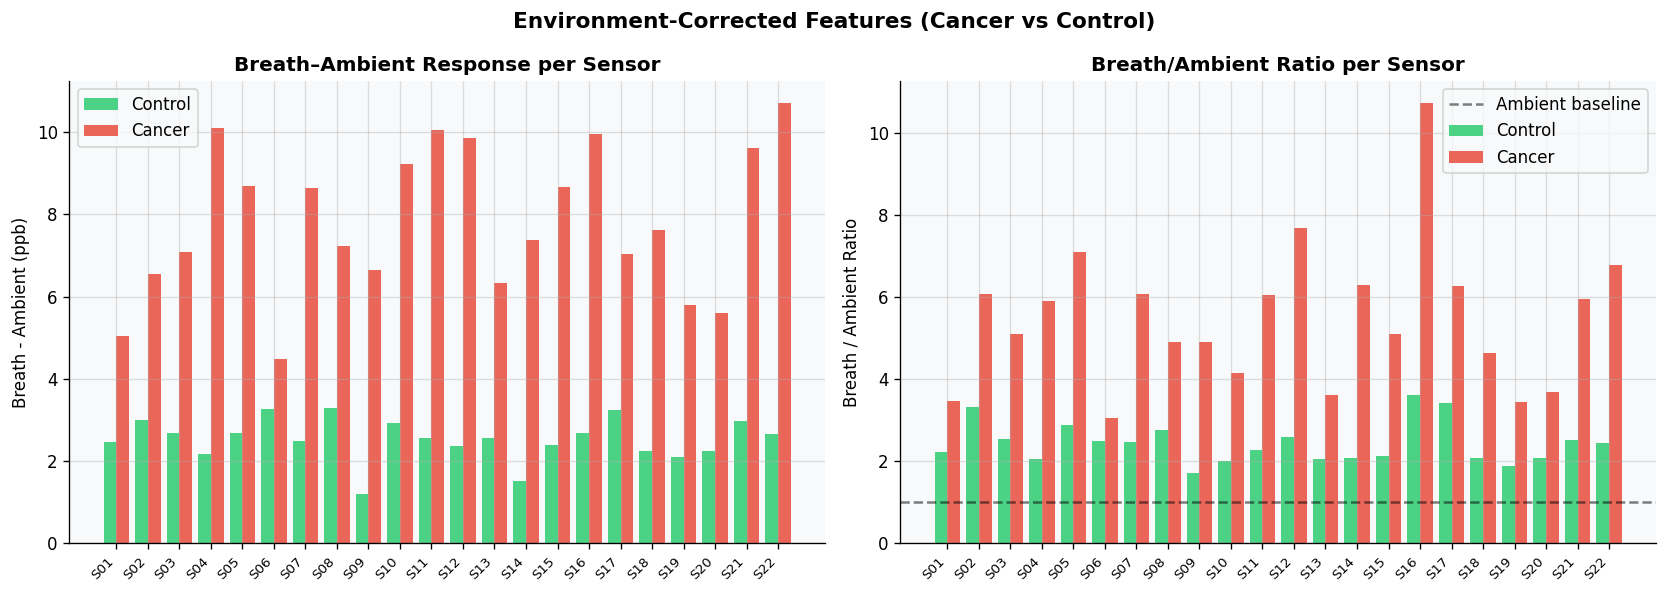

   Environment features computed
   Core features        : 22 sensors × 6 = 132
   Environment features : 22 sensors × 5 = 110
   Total feature vector : 242 dimensions


In [24]:
def extract_environment_features(breath_peaks, zero_peaks, ambient_peaks,
                                   epsilon=0.001):
    """
    Compute 5 environment-corrected features per sensor.
    
    Measurement protocol:
        1. Zero measurement   : sensor exposed to dry clean air (N2)
        2. Ambient measurement: sensor exposed to room air
        3. Breath measurement : sensor exposed to exhaled breath
    
    Args:
        breath_peaks  : array of peak responses during breath measurement
        zero_peaks    : array of peak responses during zero-air measurement
        ambient_peaks : array of peak responses during ambient measurement
        epsilon       : small constant to prevent division by zero
    
    Returns:
        dict of 5 environment-corrected features per sensor
    """
    breath  = np.array(breath_peaks,  dtype=float)
    zero    = np.array(zero_peaks,    dtype=float)
    ambient = np.array(ambient_peaks, dtype=float)
    
    # Feature 1: Breath - Zero (removes sensor drift/offset)
    breath_minus_zero = breath - zero
    
    # Feature 2: Ambient - Zero (background VOC level)
    ambient_minus_zero = ambient - zero
    
    # Feature 3: Breath - Ambient (net breath VOC above background)
    breath_minus_ambient = breath - ambient
    
    # Feature 4: Breath / Ambient ratio (normalises for environment variability)
    # epsilon prevents instability when ambient ≈ 0
    breath_over_ambient = breath / (ambient + epsilon)
    
    # Feature 5: Delta pre/post ambient (checks ambient drift during measurement)
    # In practice: compare ambient measured BEFORE vs AFTER breath measurement
    # Here we simulate a small ambient drift
    ambient_drift = ambient * 0.05  # placeholder — use real pre/post values
    delta_pre_post_ambient = ambient - ambient_drift
    
    return {
        'breath_minus_zero':         breath_minus_zero,
        'ambient_minus_zero':        ambient_minus_zero,
        'breath_minus_ambient':      breath_minus_ambient,
        'breath_over_ambient':       breath_over_ambient,
        'delta_pre_post_ambient':    delta_pre_post_ambient,
    }


# ── Demo with simulated 3-phase measurement ────────────────────────────
np.random.seed(RANDOM_STATE)
n_demo_sensors = 22

# Simulate peak responses for 22 sensors across 3 measurement phases
zero_peaks    = np.abs(np.random.normal(0.5, 0.1, n_demo_sensors))
ambient_peaks = np.abs(np.random.normal(2.0, 0.5, n_demo_sensors))
# Cancer patient: elevated breath VOC profile
breath_peaks_cancer  = ambient_peaks + np.abs(np.random.normal(8.0, 2.0, n_demo_sensors))
# Control patient: lower breath VOC profile
breath_peaks_control = ambient_peaks + np.abs(np.random.normal(2.5, 0.5, n_demo_sensors))

env_feats_cancer  = extract_environment_features(breath_peaks_cancer,  zero_peaks, ambient_peaks)
env_feats_control = extract_environment_features(breath_peaks_control, zero_peaks, ambient_peaks)

# ── Visualize environment-corrected features ──────────────────────────
sensor_labels = [f'S{i+1:02d}' for i in range(n_demo_sensors)]
feature_to_plot = 'breath_minus_ambient'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(n_demo_sensors)
axes[0].bar(x - 0.2, env_feats_control[feature_to_plot], 0.4,
            label='Control', color='#2ecc71', alpha=0.85)
axes[0].bar(x + 0.2, env_feats_cancer[feature_to_plot], 0.4,
            label='Cancer', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sensor_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Breath - Ambient (ppb)')
axes[0].set_title('Breath–Ambient Response per Sensor', fontweight='bold')
axes[0].legend()

axes[1].bar(x - 0.2, env_feats_control['breath_over_ambient'], 0.4,
            label='Control', color='#2ecc71', alpha=0.85)
axes[1].bar(x + 0.2, env_feats_cancer['breath_over_ambient'], 0.4,
            label='Cancer', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sensor_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Breath / Ambient Ratio')
axes[1].set_title('Breath/Ambient Ratio per Sensor', fontweight='bold')
axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Ambient baseline')
axes[1].legend()

plt.suptitle('Environment-Corrected Features (Cancer vs Control)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('environment_features.png', dpi=150, bbox_inches='tight')
plt.show()

total_env_features = n_demo_sensors * 5
total_features = n_demo_sensors * 6 + total_env_features
print(f'   Environment features computed')
print(f'   Core features        : {n_demo_sensors} sensors × 6 = {n_demo_sensors*6}')
print(f'   Environment features : {n_demo_sensors} sensors × 5 = {total_env_features}')
print(f'   Total feature vector : {total_features} dimensions')

## Cell 7 — Load Dataset & Binary Label Encoding

In [27]:
# Dataset: 427 patients × 27 VOC breath biomarkers
# Binary: Control=0, Cancer+Benign=1

DATA_PATH = 'LungCancer_cleaned.xlsx'
df_raw = pd.read_excel(DATA_PATH)

print('Dataset Overview')
print('=' * 50)
print(f'Shape           : {df_raw.shape}')
print(f'Patients        : {df_raw["PatientID"].nunique()}')
print(f'VOC Features    : {df_raw.shape[1] - 2}')
print(f'\nOriginal class distribution:')
for cls, cnt in df_raw['Class'].value_counts().items():
    pct = cnt / len(df_raw) * 100
    print(f'  {cls:<10} : {cnt:3d} ({pct:.1f}%)')

df_raw.rename(columns={'C4HO8O2': 'C4H8O2'}, inplace=True)
VOC_COLS = [c for c in df_raw.columns if c not in ['PatientID', 'Class']]

VOC_NAMES = {
    'CH2O':    'Formaldehyde',
    'C2H4O':   'Acetaldehyde',
    'C3H6O':   'Acetone',
    'C4H8O':   'Butanal',
    'C5H10O':  'Pentanal',
    'C6H12O':  'Hexanal',
    'C7H14O':  'Heptanal',
    'C8H16O':  'Octanal',
    'C9H18O':  'Nonanal',
    'C10H20O': 'Decanal',
    'C11H22O': 'Undecanal',
    'C12H24O': 'Dodecanal',
    'C13H26O': 'Tridecanal',
    'C4HO8O2': '3-Hydroxy-2-butanone',
    'C2H4O2':  'Hydroxy-acetaldehyde',
    'C3H4O':   'Acrolein',
    'C6H10O2': 'Caproic Acid',
    'C9H16O2': 'Azelaic Aldehyde',
    'C3H4O2':  'Acrylic Acid',
    'C4H6O2':  'Methacrylic Acid',
    'C4H6O':   'Methyl Vinyl Ketone',
    'C4H4O2':  'Succinaldehyde',
    'C5H8O':   'Cyclopentanone',
    'C7H6O':   'Benzaldehyde',
    'C7H11O':  'Pentenal',
    'C13H22O': 'Tridecenal',
    'C15H10O': 'Flavone',
}

# ── Binary label encoding ─────────────────────────────────────────────
# CLINICAL RATIONALE: Benign tumors still warrant positive screening
# to ensure follow-up; only confirmed healthy subjects are Control=0
df = df_raw.copy()
df['label'] = df['Class'].map({'Control': 0, 'Cancer': 1, 'Benign': 1})

print(f'\nBinary label encoding:')
print(f'   Control          → 0 (Negative / Healthy)')
print(f'   Cancer + Benign  → 1 (Positive / Cancer Screen)')
print(f'\n   Binary distribution:')
for lbl, cnt in df['label'].value_counts().items():
    name = 'Control' if lbl == 0 else 'Cancer+Benign'
    pct  = cnt / len(df) * 100
    print(f'   {name:<15} ({lbl}): {cnt:3d} ({pct:.1f}%)')

# ── Feature matrix ────────────────────────────────────────────────────

df[VOC_COLS] = df[VOC_COLS].clip(lower=0)

X = df[VOC_COLS].values.astype(float)
y = df['label'].values

# Handle any NaN/Inf (impute with column median)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

print(f'\nFeature matrix ready: X={X.shape}, y={y.shape}')
print(f'   NaN values remaining: {np.isnan(X).sum()}')

Dataset Overview
Shape           : (427, 29)
Patients        : 427
VOC Features    : 27

Original class distribution:
  Control    : 193 (45.2%)
  Cancer     : 157 (36.8%)
  Benign     :  77 (18.0%)

Binary label encoding:
   Control          → 0 (Negative / Healthy)
   Cancer + Benign  → 1 (Positive / Cancer Screen)

   Binary distribution:
   Cancer+Benign   (1): 234 (54.8%)
   Control         (0): 193 (45.2%)

Feature matrix ready: X=(427, 27), y=(427,)
   NaN values remaining: 0


## Cell 8 — Exploratory Data Analysis (EDA)

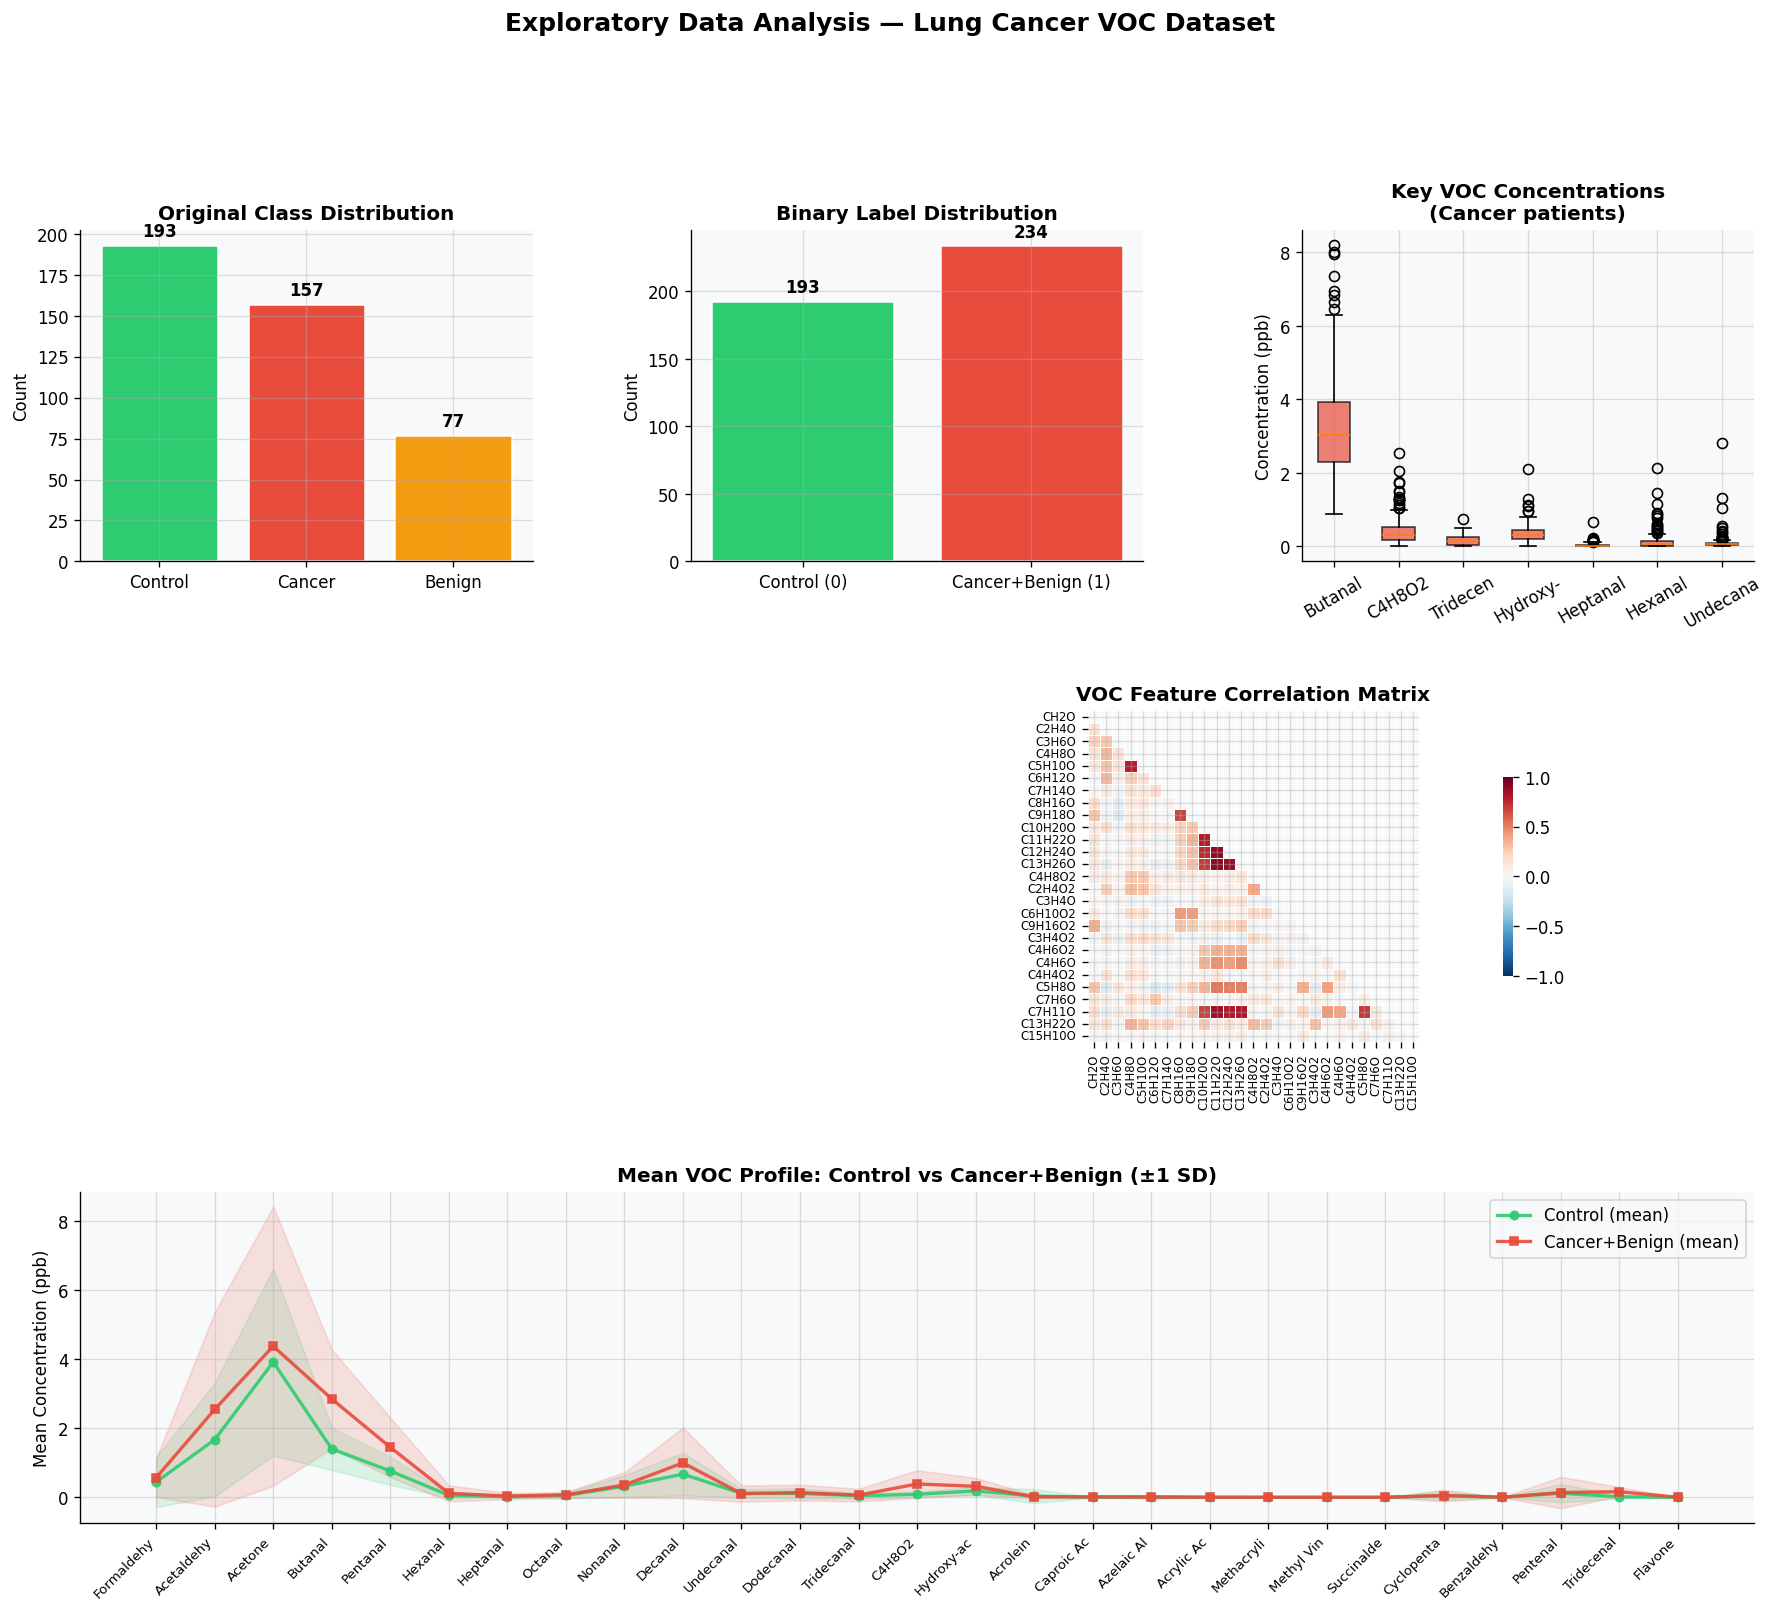

EDA complete


In [29]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 8A. Class distribution ────────────────────────────────────────────
PALETTE = {'Control': '#2ecc71', 'Cancer': '#e74c3c', 'Benign': '#f39c12'}
ax1 = fig.add_subplot(gs[0, 0])
orig_counts = df_raw['Class'].value_counts()
bars = ax1.bar(orig_counts.index, orig_counts.values,
               color=[PALETTE[c] for c in orig_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, orig_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontweight='bold')
ax1.set_title('Original Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')

# ── 8B. Binary class distribution ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bin_counts = pd.Series(y).value_counts().sort_index()
labels_bin  = ['Control (0)', 'Cancer+Benign (1)']
colors_bin  = ['#2ecc71', '#e74c3c']
bars2 = ax2.bar(labels_bin, bin_counts.values, color=colors_bin,
                edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, bin_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontweight='bold')
ax2.set_title('Binary Label Distribution', fontweight='bold')
ax2.set_ylabel('Count')

# ── 8C. Key VOC distributions (boxplot) ──────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
key_vocs = ['C4H8O', 'C4H8O2', 'C13H22O', 'C2H4O2', 'C7H14O', 'C6H12O', 'C11H22O']  # clinically relevant
df_melt = df[key_vocs + ['Class']].melt(id_vars='Class', var_name='VOC', value_name='Conc')
voc_display = [VOC_NAMES.get(v, v) for v in key_vocs]
bp = ax3.boxplot(
    [df.loc[df['Class']=='Cancer', v].values for v in key_vocs],
    patch_artist=True, labels=[VOC_NAMES.get(v, v)[:8] for v in key_vocs]
)
for patch in bp['boxes']:
    patch.set_facecolor('#e74c3c')
    patch.set_alpha(0.7)
ax3.set_title('Key VOC Concentrations\n(Cancer patients)', fontweight='bold')
ax3.set_ylabel('Concentration (ppb)')
ax3.tick_params(axis='x', rotation=30)

# ── 8D. Correlation heatmap ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
corr_matrix = pd.DataFrame(X, columns=VOC_COLS).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax4, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            xticklabels=VOC_COLS, yticklabels=VOC_COLS,
            cbar_kws={'shrink': 0.6})
ax4.set_title('VOC Feature Correlation Matrix', fontweight='bold', fontsize=12)
ax4.tick_params(axis='both', labelsize=7)

# ── 8E. Mean VOC profile: Control vs Cancer ───────────────────────────
ax5 = fig.add_subplot(gs[2, :])
mean_control = df[df['label']==0][VOC_COLS].mean()
mean_cancer  = df[df['label']==1][VOC_COLS].mean()
x_idx = np.arange(len(VOC_COLS))
ax5.plot(x_idx, mean_control.values, 'o-', color='#2ecc71', linewidth=2,
         markersize=5, label='Control (mean)', alpha=0.9)
ax5.plot(x_idx, mean_cancer.values,  's-', color='#e74c3c', linewidth=2,
         markersize=5, label='Cancer+Benign (mean)', alpha=0.9)
ax5.fill_between(x_idx,
                  df[df['label']==0][VOC_COLS].mean() - df[df['label']==0][VOC_COLS].std(),
                  df[df['label']==0][VOC_COLS].mean() + df[df['label']==0][VOC_COLS].std(),
                  alpha=0.15, color='#2ecc71')
ax5.fill_between(x_idx,
                  df[df['label']==1][VOC_COLS].mean() - df[df['label']==1][VOC_COLS].std(),
                  df[df['label']==1][VOC_COLS].mean() + df[df['label']==1][VOC_COLS].std(),
                  alpha=0.15, color='#e74c3c')
ax5.set_xticks(x_idx)
ax5.set_xticklabels([VOC_NAMES.get(v, v)[:10] for v in VOC_COLS],
                     rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Mean Concentration (ppb)')
ax5.set_title('Mean VOC Profile: Control vs Cancer+Benign (±1 SD)', fontweight='bold')
ax5.legend()

plt.suptitle('Exploratory Data Analysis — Lung Cancer VOC Dataset', 
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete')

## Cell 9 — Preprocessing: Scaling, Train/Test Split, Class Weights

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False

# ── Train / Test split (stratified to preserve class ratio) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# ── StandardScaler (fit ONLY on train, transform both) ────────────────
# CRITICAL: never fit scaler on test data — this causes data leakage
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Class weights (compensate for imbalance) ───────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

# ── SMOTE oversampling on train set (optional) ─────────────────────────
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
    print(f'SMOTE applied — train set balanced:')
    for lbl, cnt in zip(*np.unique(y_train_sm, return_counts=True)):
        print(f'  Label {lbl}: {cnt}')
else:
    X_train_sm, y_train_sm = X_train_scaled, y_train
    print('Using class_weight instead of SMOTE')

print(f'\nData splits:')
print(f'   Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nClass weights: {class_weights}')
print(f'\nPreprocessing complete — ready for feature selection')

SMOTE applied — train set balanced:
  Label 0: 187
  Label 1: 187

Data splits:
   Train : 341 samples (80%)
   Test  : 86 samples (20%)

Class weights: {0: 1.1071428571428572, 1: 0.9117647058823529}

Preprocessing complete — ready for feature selection


## Cell 10 — SVM-RFE Feature Selection (RFECV)

In [33]:
# Finds optimal feature subset using recursive elimination
# Linear SVM ranks features by |w| coefficient magnitude

print('Running SVM-RFE (RFECV)...')
print(f'   Features input : {X_train_scaled.shape[1]}')
print(f'   CV strategy    : {N_FOLDS}-fold Stratified')
print(f'   Scoring        : ROC-AUC')
print()

# SVM with linear kernel — required for RFE (needs coef_ attribute)
svm_linear = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',  # handles imbalance
    random_state=RANDOM_STATE,
    probability=False         # not needed for RFE step
)

rfecv = RFECV(
    estimator=svm_linear,
    step=1,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    min_features_to_select=3,
    n_jobs=-1
)

rfecv.fit(X_train_scaled, y_train)

# ── Results ───────────────────────────────────────────────────────────
selected_mask   = rfecv.support_
selected_features = [VOC_COLS[i] for i in range(len(VOC_COLS)) if selected_mask[i]]
selected_names    = [VOC_NAMES.get(f, f) for f in selected_features]
feature_rankings  = rfecv.ranking_  # 1 = selected, higher = eliminated earlier

# Reduce feature matrices
X_train_rfe = rfecv.transform(X_train_scaled)
X_test_rfe  = rfecv.transform(X_test_scaled)

print(f'SVM-RFE complete')
print(f'   Optimal features : {rfecv.n_features_} / {len(VOC_COLS)}')
print(f'   Best CV AUC      : {max(rfecv.cv_results_["mean_test_score"]):.4f}')
print(f'\n   Selected features:')
for formula, name in zip(selected_features, selected_names):
    print(f'{formula:<12} ({name})')

Running SVM-RFE (RFECV)...
   Features input : 27
   CV strategy    : 5-fold Stratified
   Scoring        : ROC-AUC

SVM-RFE complete
   Optimal features : 5 / 27
   Best CV AUC      : 0.9507

   Selected features:
C4H8O        (Butanal)
C10H20O      (Decanal)
C11H22O      (Undecanal)
C4H8O2       (C4H8O2)
C13H22O      (Tridecenal)


## Cell 11 — RFE Results Visualization

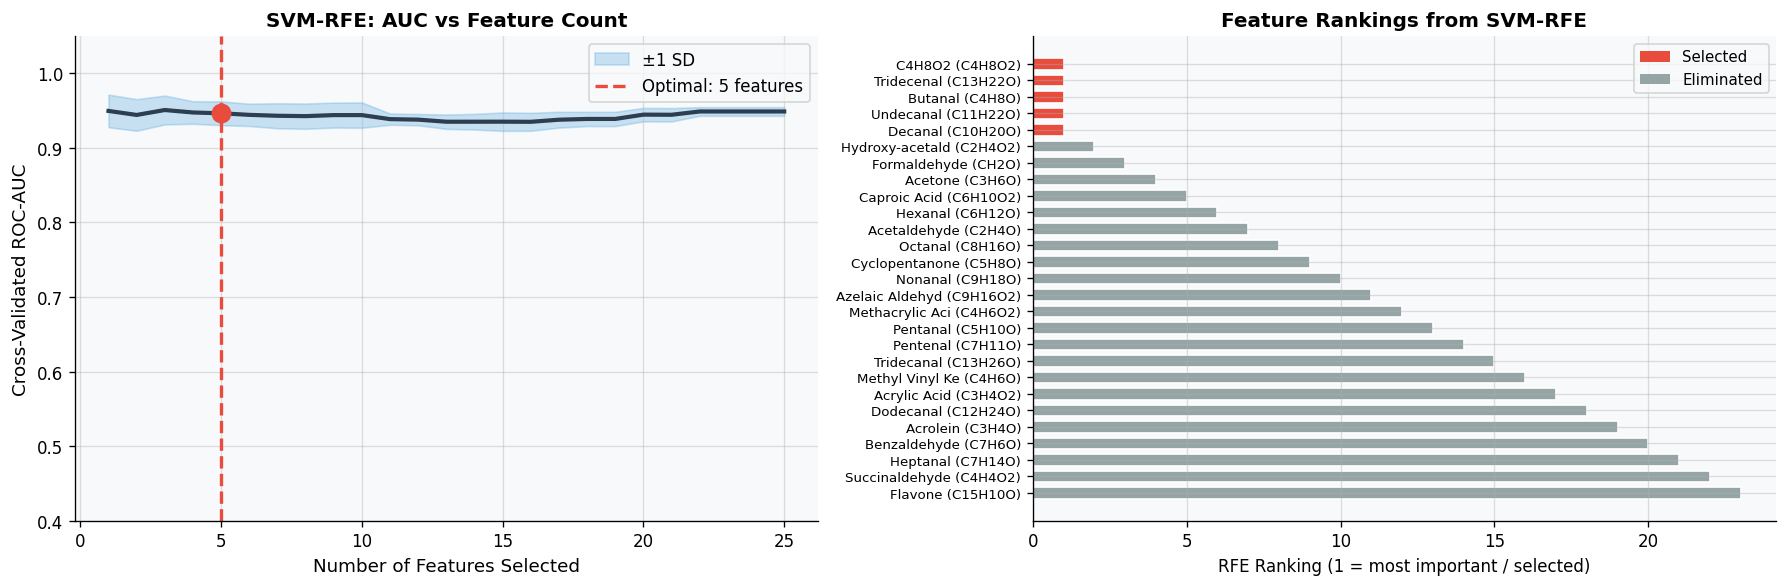

Full Feature Ranking Table:
formula              feature  ranking  selected
 C4H8O2               C4H8O2        1      True
C13H22O           Tridecenal        1      True
  C4H8O              Butanal        1      True
C11H22O            Undecanal        1      True
C10H20O              Decanal        1      True
 C2H4O2 Hydroxy-acetaldehyde        2     False
   CH2O         Formaldehyde        3     False
  C3H6O              Acetone        4     False
C6H10O2         Caproic Acid        5     False
 C6H12O              Hexanal        6     False
  C2H4O         Acetaldehyde        7     False
 C8H16O              Octanal        8     False
  C5H8O       Cyclopentanone        9     False
 C9H18O              Nonanal       10     False
C9H16O2     Azelaic Aldehyde       11     False
 C4H6O2     Methacrylic Acid       12     False
 C5H10O             Pentanal       13     False
 C7H11O             Pentenal       14     False
C13H26O           Tridecanal       15     False
  C4H6O  Met

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 11A. CV AUC vs Number of Features ────────────────────────────────
n_features_range = range(1, len(rfecv.cv_results_['mean_test_score']) + 1)
mean_scores = rfecv.cv_results_['mean_test_score']
std_scores  = rfecv.cv_results_['std_test_score']

axes[0].plot(n_features_range, mean_scores,
             color='#2c3e50', linewidth=2.5, zorder=5)
axes[0].fill_between(n_features_range,
                      np.array(mean_scores) - np.array(std_scores),
                      np.array(mean_scores) + np.array(std_scores),
                      alpha=0.25, color='#3498db', label='±1 SD')
axes[0].axvline(rfecv.n_features_, color='#e74c3c', linestyle='--',
                 linewidth=2, label=f'Optimal: {rfecv.n_features_} features')
axes[0].scatter([rfecv.n_features_],
                 [mean_scores[rfecv.n_features_-1]],
                 color='#e74c3c', s=120, zorder=10)
axes[0].set_xlabel('Number of Features Selected', fontsize=11)
axes[0].set_ylabel('Cross-Validated ROC-AUC', fontsize=11)
axes[0].set_title('SVM-RFE: AUC vs Feature Count', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.4, 1.05)

# ── 11B. Feature Ranking (all features) ──────────────────────────────
rank_df = pd.DataFrame({
    'feature': [VOC_NAMES.get(v, v) for v in VOC_COLS],
    'formula': VOC_COLS,
    'ranking': feature_rankings,
    'selected': selected_mask
}).sort_values('ranking')

colors_rank = ['#e74c3c' if s else '#95a5a6' for s in rank_df['selected']]
bars = axes[1].barh(range(len(rank_df)), rank_df['ranking'],
                     color=colors_rank, edgecolor='white', height=0.7)
axes[1].set_yticks(range(len(rank_df)))
axes[1].set_yticklabels(
    [f"{row['feature'][:15]} ({row['formula']})" for _, row in rank_df.iterrows()],
    fontsize=8
)
axes[1].set_xlabel('RFE Ranking (1 = most important / selected)', fontsize=10)
axes[1].set_title('Feature Rankings from SVM-RFE', fontweight='bold', fontsize=12)
legend_elements = [Patch(facecolor='#e74c3c', label='Selected'),
                   Patch(facecolor='#95a5a6', label='Eliminated')]
axes[1].legend(handles=legend_elements, fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('rfe_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking table
print('Full Feature Ranking Table:')
print(rank_df[['formula', 'feature', 'ranking', 'selected']].to_string(index=False))

## Cell 12 — Model Training: SVM-RBF & Gradient Boosting

In [35]:
from sklearn.model_selection import GridSearchCV

cv_strat = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ══════════════════════════════════════════════════════
# MODEL 1: SVM with RBF Kernel (primary classifier)
# ══════════════════════════════════════════════════════
print('Training SVM-RBF with hyperparameter search...')

svm_param_grid = {
    'C':     [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_rbf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

svm_grid = GridSearchCV(
    svm_rbf, svm_param_grid,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_train_rfe, y_train)
best_svm = svm_grid.best_estimator_

print(f'   Best SVM params  : {svm_grid.best_params_}')
print(f'   Best CV AUC      : {svm_grid.best_score_:.4f}')

# ══════════════════════════════════════════════════════
# MODEL 2: Gradient Boosting Machine (comparison)
# ══════════════════════════════════════════════════════
print('\nTraining Gradient Boosting Classifier...')

gbm = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gbm.fit(X_train_rfe, y_train)

# GBM CV score
gbm_cv_auc = cross_val_score(
    gbm, X_train_rfe, y_train,
    cv=cv_strat, scoring='roc_auc', n_jobs=-1
)
print(f'   GBM CV AUC: {gbm_cv_auc.mean():.4f} ± {gbm_cv_auc.std():.4f}')

# ══════════════════════════════════════════════════════
# MODEL 3: Random Forest (for feature importance)
# ══════════════════════════════════════════════════════
print('\nTraining Random Forest (for feature importance)...')

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_rfe, y_train)

rf_cv_auc = cross_val_score(
    rf, X_train_rfe, y_train,
    cv=cv_strat, scoring='roc_auc', n_jobs=-1
)
print(f'   RF CV AUC : {rf_cv_auc.mean():.4f} ± {rf_cv_auc.std():.4f}')

print('\nAll models trained')

Training SVM-RBF with hyperparameter search...
   Best SVM params  : {'C': 10.0, 'gamma': 'auto'}
   Best CV AUC      : 0.9660

Training Gradient Boosting Classifier...
   GBM CV AUC: 0.9647 ± 0.0215

Training Random Forest (for feature importance)...
   RF CV AUC : 0.9698 ± 0.0181

All models trained


## Cell 13 — Model Evaluation: ROC, Confusion Matrix, Metrics

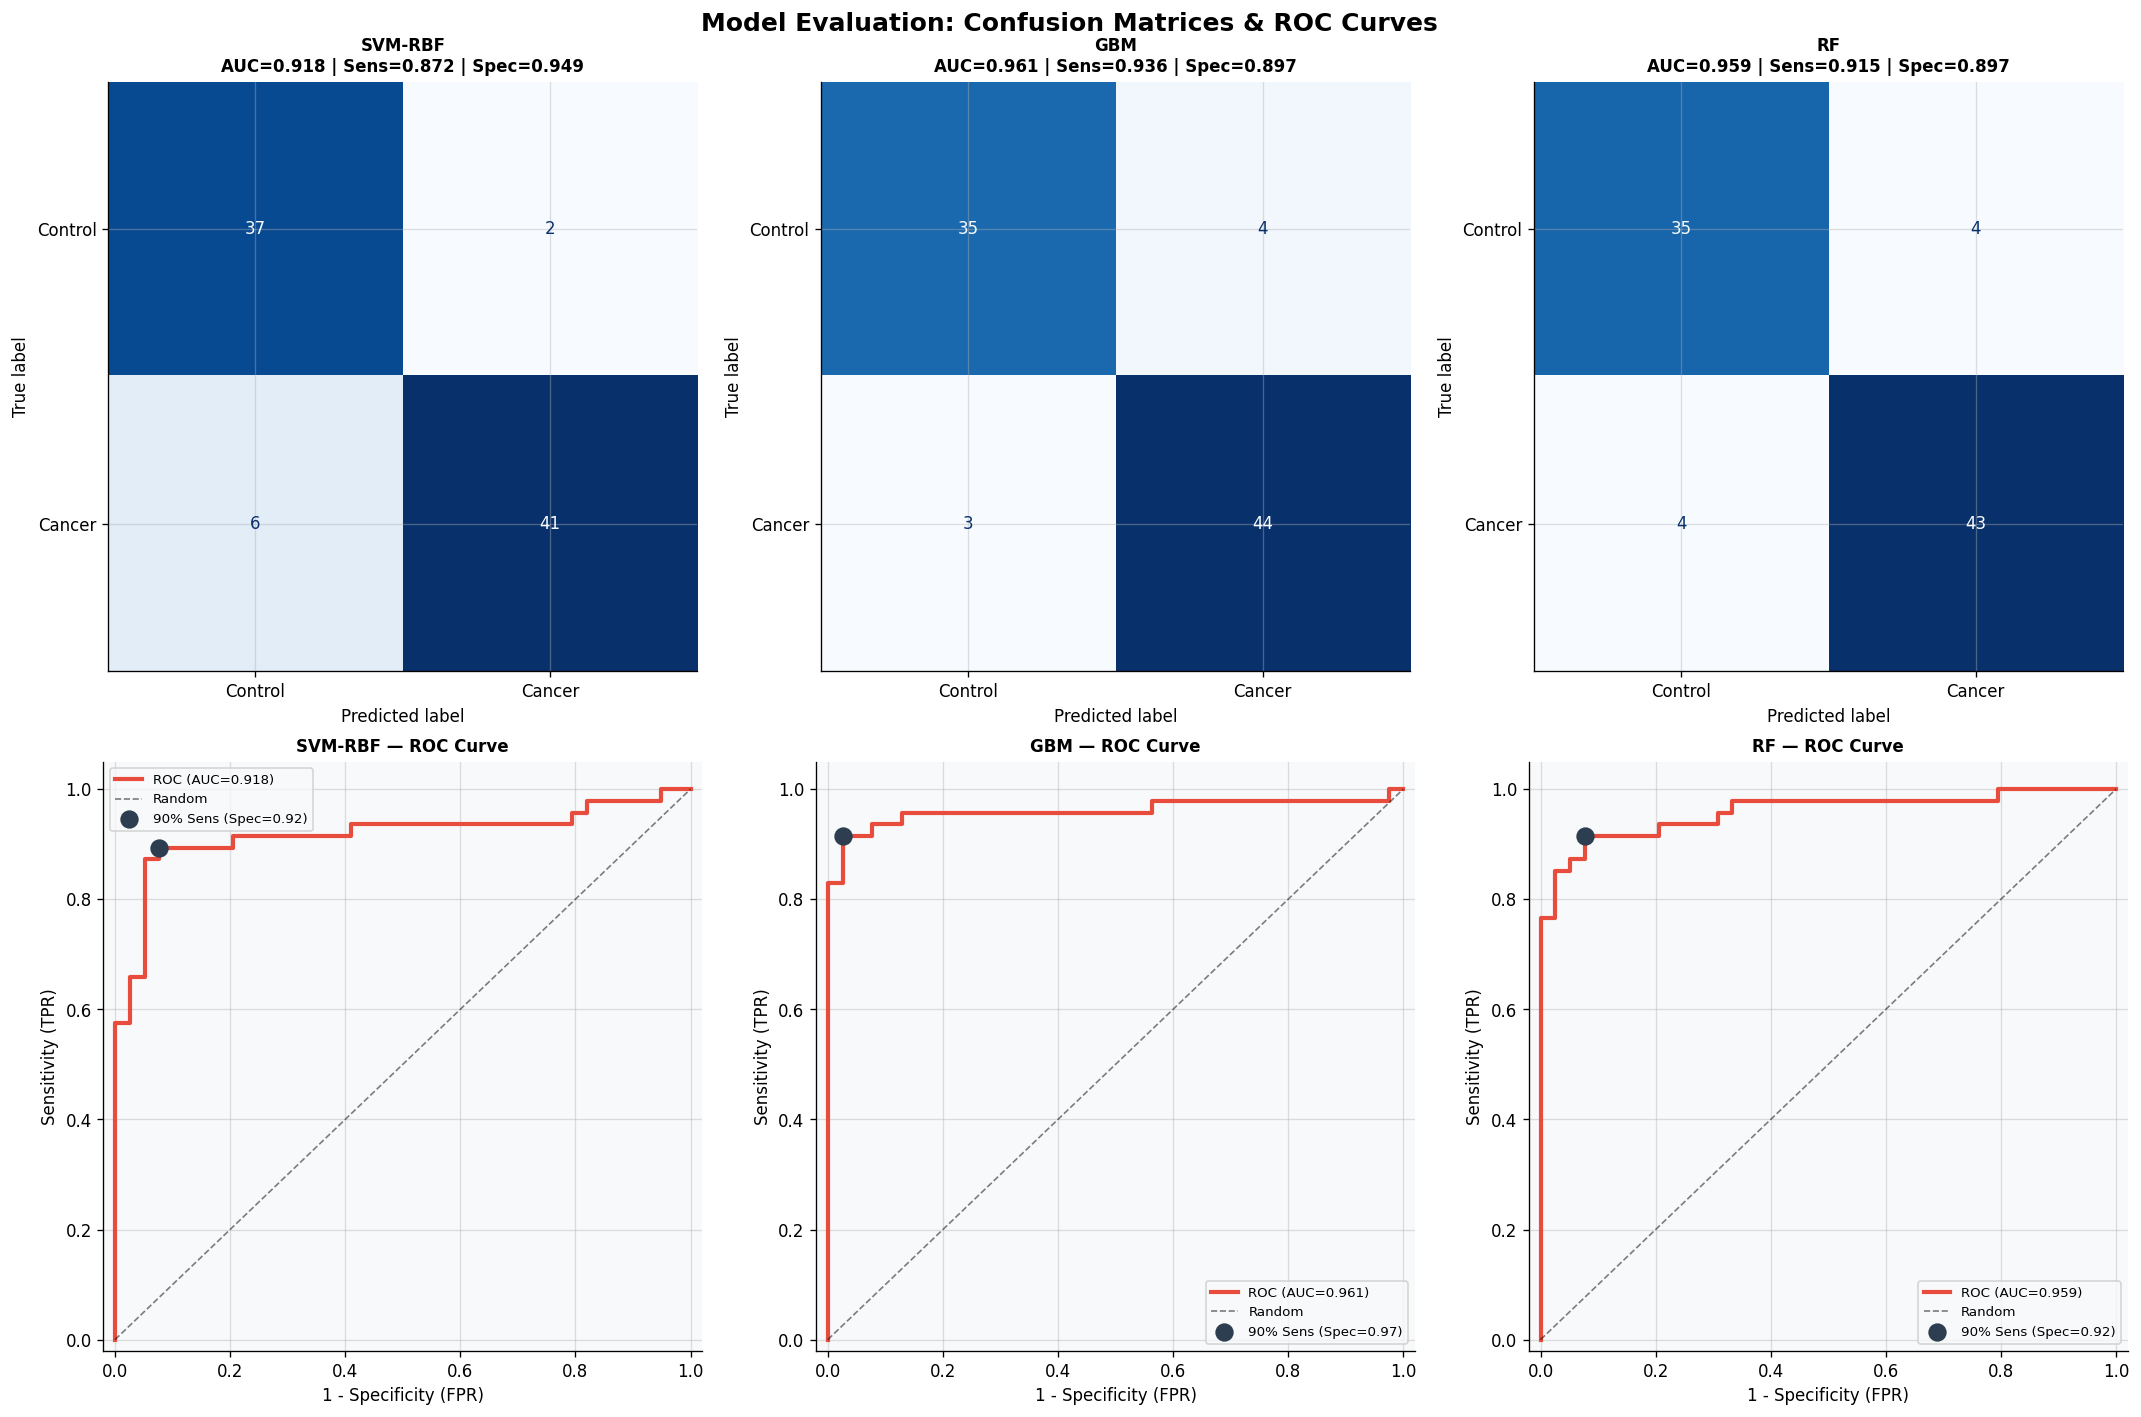


Model Performance Summary (Test Set)
Model           AUC   Sens   Spec    PPV    NPV     F1
---------------------------------------------------------------------------
SVM-RBF       0.918  0.872  0.949  0.953  0.860  0.911
GBM           0.961  0.936  0.897  0.917  0.921  0.926
RF            0.959  0.915  0.897  0.915  0.897  0.915


In [36]:
models = {
    'SVM-RBF':  best_svm,
    'GBM':      gbm,
    'RF':       rf,
}

results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col_idx, (model_name, model) in enumerate(models.items()):
    y_pred      = model.predict(X_test_rfe)
    y_prob      = model.predict_proba(X_test_rfe)[:, 1]
    
    auc  = roc_auc_score(y_test, y_prob)
    ap   = average_precision_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)  # recall for cancer
    specificity = tn / (tn + fp)  # recall for control
    ppv         = tp / (tp + fp)  # precision
    npv         = tn / (tn + fn)
    f1          = 2 * (ppv * sensitivity) / (ppv + sensitivity)
    
    results[model_name] = {
        'AUC': auc, 'AP': ap, 'Sensitivity': sensitivity,
        'Specificity': specificity, 'PPV': ppv, 'NPV': npv, 'F1': f1,
        'y_prob': y_prob, 'y_pred': y_pred
    }
    
    # ── Confusion Matrix ────────────────────────────────────────────
    ax_cm = axes[0, col_idx]
    disp = ConfusionMatrixDisplay(cm, display_labels=['Control', 'Cancer'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(
        f'{model_name}\nAUC={auc:.3f} | Sens={sensitivity:.3f} | Spec={specificity:.3f}',
        fontweight='bold', fontsize=10
    )
    
    # ── ROC Curve ───────────────────────────────────────────────────
    ax_roc = axes[1, col_idx]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
                label=f'ROC (AUC={auc:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
    # Mark operating point at 90% sensitivity
    idx_90 = np.argmin(np.abs(tpr - 0.90))
    ax_roc.scatter(fpr[idx_90], tpr[idx_90],
                    color='#2c3e50', s=100, zorder=10,
                    label=f'90% Sens (Spec={1-fpr[idx_90]:.2f})')
    ax_roc.set_xlabel('1 - Specificity (FPR)', fontsize=10)
    ax_roc.set_ylabel('Sensitivity (TPR)', fontsize=10)
    ax_roc.set_title(f'{model_name} — ROC Curve', fontweight='bold', fontsize=10)
    ax_roc.legend(fontsize=8)
    ax_roc.set_xlim(-0.02, 1.02)
    ax_roc.set_ylim(-0.02, 1.05)

plt.suptitle('Model Evaluation: Confusion Matrices & ROC Curves',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────
print('\nModel Performance Summary (Test Set)')
print('=' * 75)
print(f'{"Model":<12} {"AUC":>6} {"Sens":>6} {"Spec":>6} {"PPV":>6} {"NPV":>6} {"F1":>6}')
print('-' * 75)
for name, r in results.items():
    print(f'{name:<12} {r["AUC"]:>6.3f} {r["Sensitivity"]:>6.3f} '
          f'{r["Specificity"]:>6.3f} {r["PPV"]:>6.3f} {r["NPV"]:>6.3f} {r["F1"]:>6.3f}')

## Cell 14 — Clinical Threshold Tuning

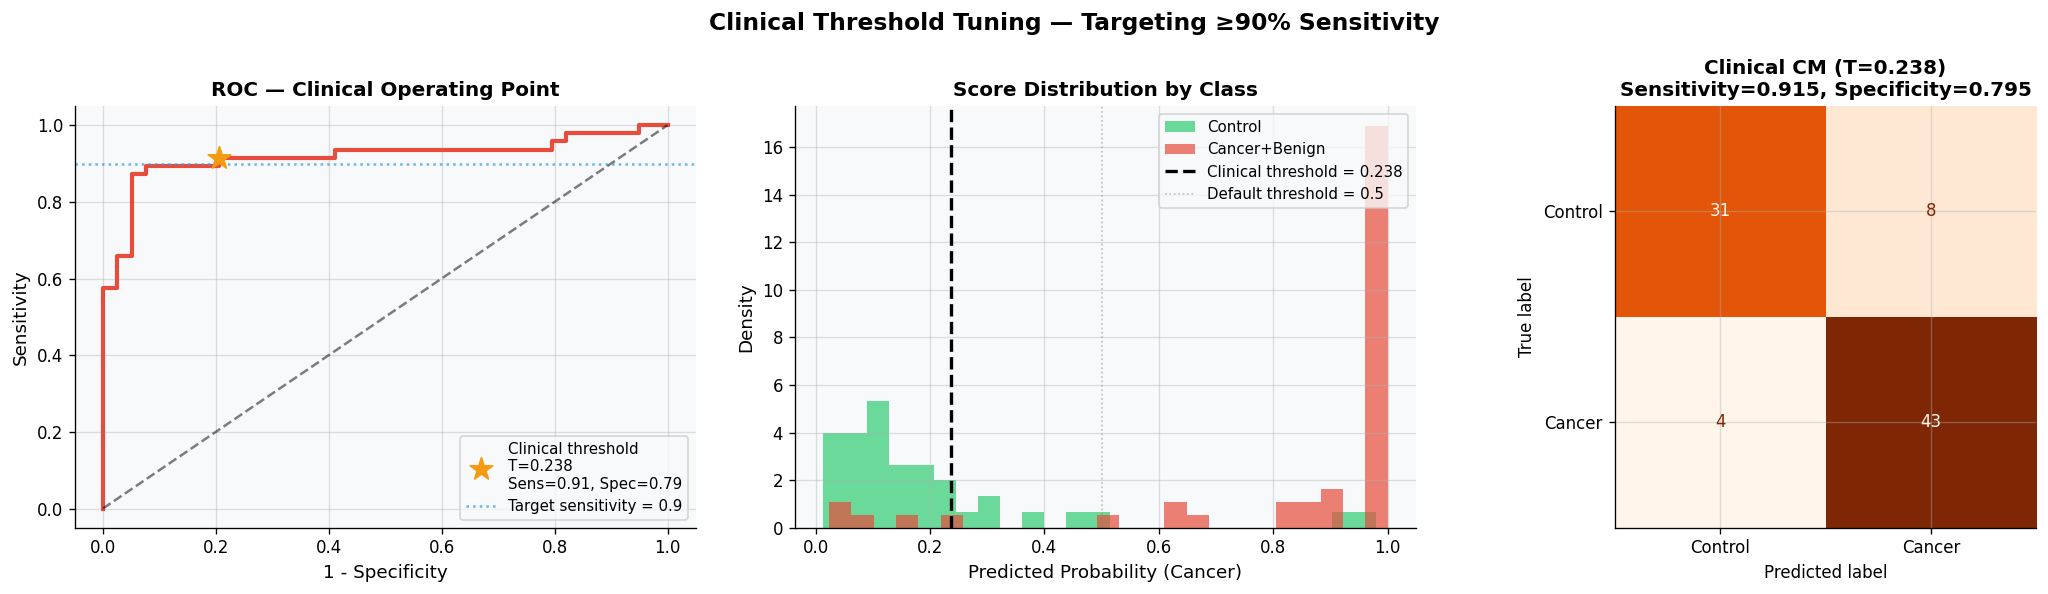


 Clinical Performance Report
   Decision threshold   : 0.2375
   Sensitivity (Recall) : 0.9149  ← minimize missed cancers
   Specificity          : 0.7949  ← avoid unnecessary referrals
   True Positives (TP)  : 43
   False Negatives (FN) : 4  ← missed cancers
   True Negatives (TN)  : 31
   False Positives (FP) : 8

   Clinical classification report:
               precision    recall  f1-score   support

      Control       0.89      0.79      0.84        39
Cancer+Benign       0.84      0.91      0.88        47

     accuracy                           0.86        86
    macro avg       0.86      0.85      0.86        86
 weighted avg       0.86      0.86      0.86        86



In [37]:
# In cancer screening, SENSITIVITY is the priority metric:
# We must minimize False Negatives (missed cancers).
# Tune decision threshold to achieve ≥90% sensitivity.

TARGET_SENSITIVITY = 0.90
PRIMARY_MODEL_NAME = 'SVM-RBF'
primary_model = best_svm
y_prob_primary = results[PRIMARY_MODEL_NAME]['y_prob']

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_primary)

# Find threshold where sensitivity ≥ 90%
valid_idx = np.where(tpr >= TARGET_SENSITIVITY)[0]
if len(valid_idx) > 0:
    # Among valid, pick the one with highest specificity (lowest FPR)
    best_idx = valid_idx[np.argmin(fpr[valid_idx])]
else:
    best_idx = np.argmin(np.abs(tpr - TARGET_SENSITIVITY))

optimal_threshold = thresholds[best_idx]
achieved_sensitivity = tpr[best_idx]
achieved_specificity = 1 - fpr[best_idx]

# Apply clinical threshold
y_pred_clinical = (y_prob_primary >= optimal_threshold).astype(int)
cm_clinical     = confusion_matrix(y_test, y_pred_clinical)
tn, fp, fn, tp  = cm_clinical.ravel()

# ── Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC with threshold marked
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2.5)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].scatter(fpr[best_idx], tpr[best_idx],
                color='#f39c12', s=200, zorder=10, marker='*',
                label=f'Clinical threshold\nT={optimal_threshold:.3f}\nSens={achieved_sensitivity:.2f}, Spec={achieved_specificity:.2f}')
axes[0].axhline(TARGET_SENSITIVITY, color='#3498db', linestyle=':', alpha=0.7,
                label=f'Target sensitivity = {TARGET_SENSITIVITY}')
axes[0].set_xlabel('1 - Specificity', fontsize=11)
axes[0].set_ylabel('Sensitivity', fontsize=11)
axes[0].set_title('ROC — Clinical Operating Point', fontweight='bold')
axes[0].legend(fontsize=9)

# Probability distribution
axes[1].hist(y_prob_primary[y_test==0], bins=25, alpha=0.7,
             color='#2ecc71', label='Control', density=True)
axes[1].hist(y_prob_primary[y_test==1], bins=25, alpha=0.7,
             color='#e74c3c', label='Cancer+Benign', density=True)
axes[1].axvline(optimal_threshold, color='black', linewidth=2, linestyle='--',
                label=f'Clinical threshold = {optimal_threshold:.3f}')
axes[1].axvline(0.5, color='gray', linewidth=1, linestyle=':', alpha=0.5,
                label='Default threshold = 0.5')
axes[1].set_xlabel('Predicted Probability (Cancer)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Score Distribution by Class', fontweight='bold')
axes[1].legend(fontsize=9)

# Clinical confusion matrix
disp = ConfusionMatrixDisplay(cm_clinical, display_labels=['Control', 'Cancer'])
disp.plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title(
    f'Clinical CM (T={optimal_threshold:.3f})\n'
    f'Sensitivity={achieved_sensitivity:.3f}, Specificity={achieved_specificity:.3f}',
    fontweight='bold'
)

plt.suptitle('Clinical Threshold Tuning — Targeting ≥90% Sensitivity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clinical_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Clinical Performance Report')
print('=' * 50)
print(f'   Decision threshold   : {optimal_threshold:.4f}')
print(f'   Sensitivity (Recall) : {achieved_sensitivity:.4f}  ← minimize missed cancers')
print(f'   Specificity          : {achieved_specificity:.4f}  ← avoid unnecessary referrals')
print(f'   True Positives (TP)  : {tp}')
print(f'   False Negatives (FN) : {fn}  ← missed cancers')
print(f'   True Negatives (TN)  : {tn}')
print(f'   False Positives (FP) : {fp}')
print(f'\n   Clinical classification report:')
print(classification_report(y_test, y_pred_clinical,
                              target_names=['Control', 'Cancer+Benign']))

## Cell 15 — Feature Importance

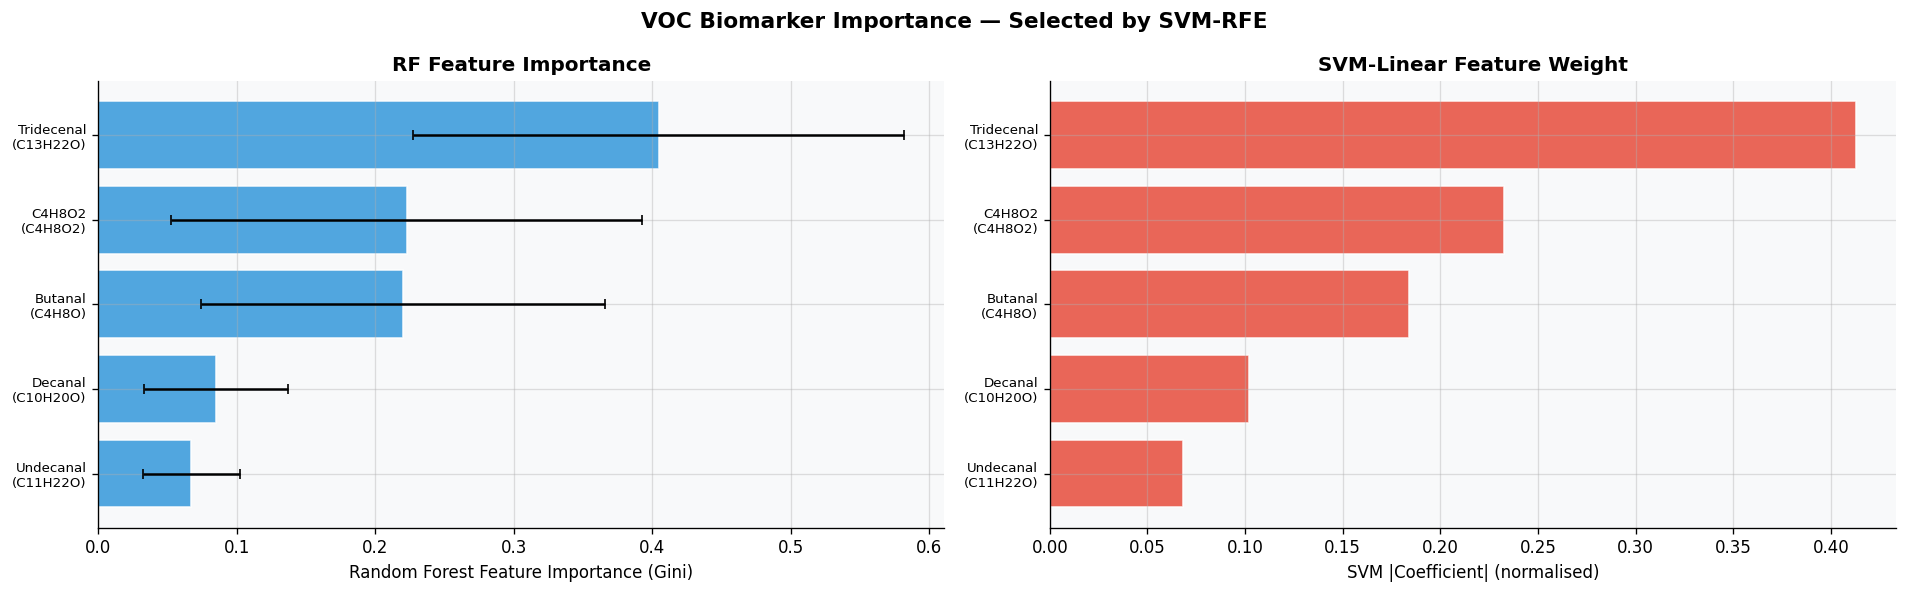

Top Discriminative VOC Biomarkers (Composite Rank):
formula       name  rf_importance  svm_coef  composite
C13H22O Tridecenal       0.404564  0.412776   0.408670
 C4H8O2     C4H8O2       0.222679  0.232645   0.227662
  C4H8O    Butanal       0.220210  0.184113   0.202162
C10H20O    Decanal       0.085227  0.102167   0.093697
C11H22O  Undecanal       0.067319  0.068299   0.067809


In [38]:
# ── RF feature importances (Gini impurity) ────────────────────────────
rf_importances = rf.feature_importances_
rf_std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# ── SVM coefficient magnitudes (re-train linear SVM on RFE features) ──
svm_lin_final = SVC(kernel='linear', C=1.0, class_weight='balanced',
                     probability=False, random_state=RANDOM_STATE)
svm_lin_final.fit(X_train_rfe, y_train)
svm_coef_abs = np.abs(svm_lin_final.coef_[0])

# Build importance dataframe
imp_df = pd.DataFrame({
    'formula':     selected_features,
    'name':        selected_names,
    'rf_importance': rf_importances,
    'rf_std':        rf_std,
    'svm_coef':      svm_coef_abs / svm_coef_abs.sum(),  # normalize
}).sort_values('rf_importance', ascending=False)

# Composite rank score
imp_df['composite'] = (imp_df['rf_importance'] / imp_df['rf_importance'].sum() +
                        imp_df['svm_coef']) / 2
imp_df = imp_df.sort_values('composite', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(selected_features) * 0.4 + 2)))

# RF importance
y_pos = np.arange(len(imp_df))
axes[0].barh(y_pos, imp_df['rf_importance'],
              xerr=imp_df['rf_std'], color='#3498db',
              alpha=0.85, edgecolor='white', capsize=3)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(
    [f"{row['name'][:14]}\n({row['formula']})" for _, row in imp_df.iterrows()],
    fontsize=8
)
axes[0].set_xlabel('Random Forest Feature Importance (Gini)', fontsize=10)
axes[0].set_title('RF Feature Importance', fontweight='bold')
axes[0].invert_yaxis()

# SVM coefficient
axes[1].barh(y_pos, imp_df['svm_coef'],
              color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    [f"{row['name'][:14]}\n({row['formula']})" for _, row in imp_df.iterrows()],
    fontsize=8
)
axes[1].set_xlabel('SVM |Coefficient| (normalised)', fontsize=10)
axes[1].set_title('SVM-Linear Feature Weight', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('VOC Biomarker Importance — Selected by SVM-RFE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top Discriminative VOC Biomarkers (Composite Rank):')
print(imp_df[['formula', 'name', 'rf_importance', 'svm_coef', 'composite']].to_string(index=False))

## Cell 16 — Cross-Validation Summary

Cross-Validation Results (5-fold Stratified)
Model               AUC   Sensitivity   Precision         F1
---------------------------------------------------------------------------
SVM-RBF      0.966±0.021  0.883±0.032   0.944±0.030  0.911±0.015
GBM          0.965±0.021  0.899±0.043   0.934±0.057  0.913±0.018
RF           0.970±0.018  0.909±0.040   0.930±0.064  0.917±0.031


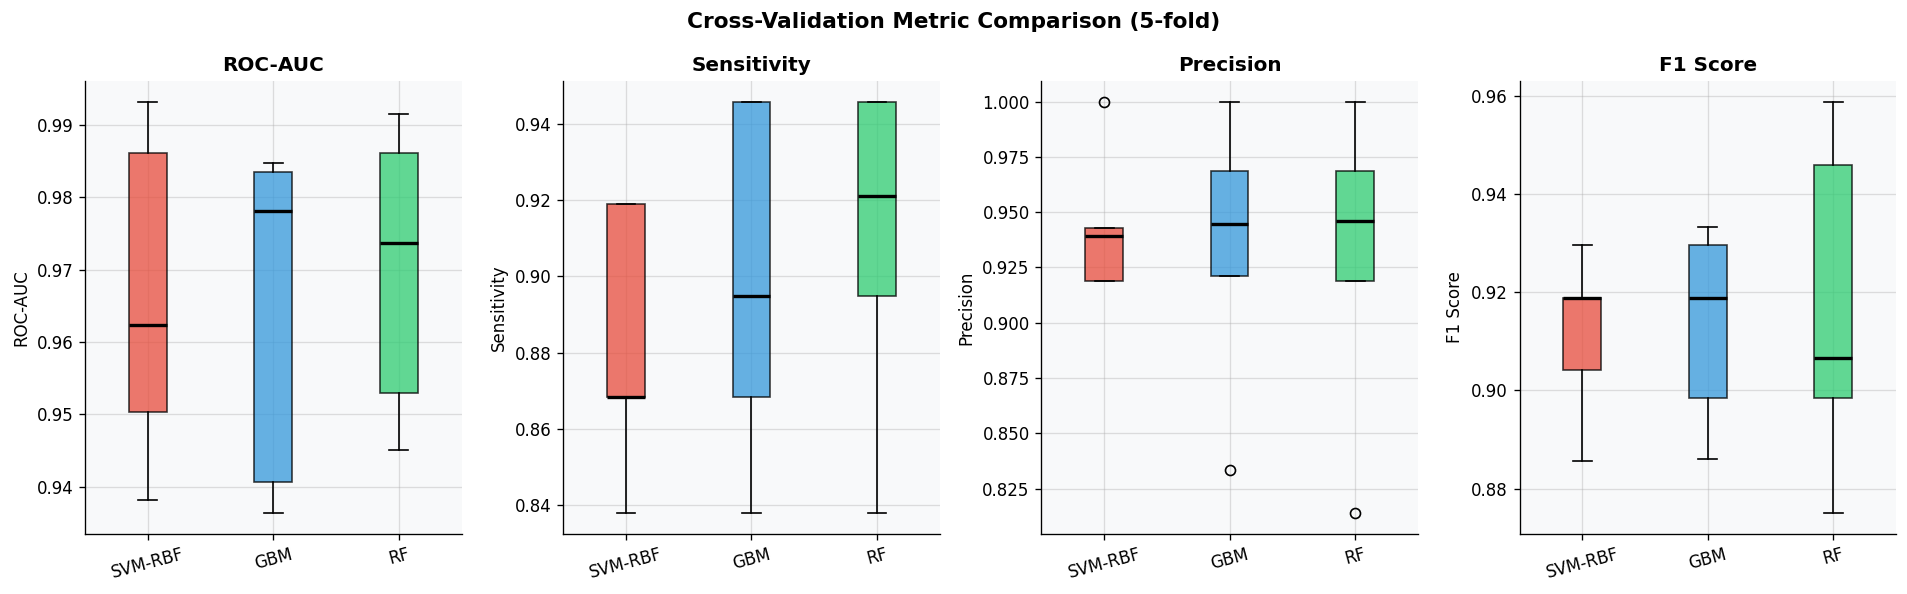

In [39]:
from sklearn.model_selection import cross_validate

scoring_metrics = {
    'roc_auc':   'roc_auc',
    'sensitivity': 'recall',
    'precision': 'precision',
    'f1':        'f1',
    'accuracy':  'accuracy',
}

cv_results_all = {}

print('Cross-Validation Results (5-fold Stratified)')
print('=' * 75)
print(f'{"Model":<12} {"AUC":>10} {"Sensitivity":>13} {"Precision":>11} {"F1":>10}')
print('-' * 75)

for model_name, model in models.items():
    cv_res = cross_validate(
        model, X_train_rfe, y_train,
        cv=cv_strat,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False
    )
    cv_results_all[model_name] = cv_res
    
    auc_m   = cv_res['test_roc_auc'].mean()
    auc_s   = cv_res['test_roc_auc'].std()
    sens_m  = cv_res['test_sensitivity'].mean()
    sens_s  = cv_res['test_sensitivity'].std()
    prec_m  = cv_res['test_precision'].mean()
    prec_s  = cv_res['test_precision'].std()
    f1_m    = cv_res['test_f1'].mean()
    f1_s    = cv_res['test_f1'].std()
    
    print(f'{model_name:<12} '
          f'{auc_m:.3f}±{auc_s:.3f}  '
          f'{sens_m:.3f}±{sens_s:.3f}   '
          f'{prec_m:.3f}±{prec_s:.3f}  '
          f'{f1_m:.3f}±{f1_s:.3f}')

# ── Boxplot comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metric_keys = ['test_roc_auc', 'test_sensitivity', 'test_precision', 'test_f1']
metric_labels = ['ROC-AUC', 'Sensitivity', 'Precision', 'F1 Score']

for ax, metric_key, metric_label in zip(axes, metric_keys, metric_labels):
    data = [cv_results_all[m][metric_key] for m in models.keys()]
    bp = ax.boxplot(data, patch_artist=True,
                     labels=list(models.keys()),
                     medianprops=dict(color='black', linewidth=2))
    colors_box = ['#e74c3c', '#3498db', '#2ecc71']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_ylabel(metric_label, fontsize=10)
    ax.set_title(metric_label, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Validation Metric Comparison (5-fold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Save Model & Scaler for Deployment

In [41]:
import os

SAVE_DIR = 'saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save components ───────────────────────────────────────────────────
joblib.dump(scaler,        f'{SAVE_DIR}/scaler.pkl')
joblib.dump(rfecv,         f'{SAVE_DIR}/rfecv_selector.pkl')
joblib.dump(best_svm,      f'{SAVE_DIR}/svm_rbf_model.pkl')
joblib.dump(gbm,           f'{SAVE_DIR}/gbm_model.pkl')
joblib.dump(rf,            f'{SAVE_DIR}/rf_model.pkl')
joblib.dump(imputer,       f'{SAVE_DIR}/imputer.pkl')

# ── Save metadata ─────────────────────────────────────────────────────
import json

metadata = {
    'pipeline_version':      '1.0',
    'n_input_features':      len(VOC_COLS),
    'input_feature_names':   VOC_COLS,
    'n_selected_features':   rfecv.n_features_,
    'selected_features':     selected_features,
    'selected_feature_names': selected_names,
    'label_mapping':         {'Control': 0, 'Cancer': 1, 'Benign': 1},
    'binary_labels':         {'0': 'Control (Healthy)', '1': 'Cancer+Benign (Positive)'},
    'clinical_threshold':    float(optimal_threshold),
    'target_sensitivity':    TARGET_SENSITIVITY,
    'achieved_sensitivity':  float(achieved_sensitivity),
    'achieved_specificity':  float(achieved_specificity),
    'primary_model':         PRIMARY_MODEL_NAME,
    'test_auc':              float(results[PRIMARY_MODEL_NAME]['AUC']),
    'sensor_array':          {
        'total': 22,
        'MOS': 10, 'EC': 8, 'PID': 1, 'QCM': 2
    },
    'calibration_models':    {
        'MOS': {'type': 'power_law', 'params': mos_params},
        'EC':  {'type': 'linear', 'params': ec_params},
        'PID': {'type': 'linear_with_RF', 'params': pid_params}
    }
}

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

with open(f'{SAVE_DIR}/pipeline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, cls=NumpyEncoder)

print('Pipeline saved to:', SAVE_DIR)
for fname in os.listdir(SAVE_DIR):
    fsize = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f'   {fname:<35} {fsize/1024:.1f} KB')

# ── Deployment inference function ─────────────────────────────────────
def predict_patient(raw_voc_array, threshold=None):
    """
    Full inference pipeline for a new patient.
    
    Args:
        raw_voc_array : 1D array of 27 VOC concentrations (ppb)
                        in the same order as VOC_COLS
        threshold     : decision threshold (default: clinical threshold)
    
    Returns:
        dict with prediction, probability, and confidence
    """
    if threshold is None:
        threshold = optimal_threshold
    
    # 1. Impute missing values
    X_new = imputer.transform([raw_voc_array])
    # 2. Scale
    X_scaled_new = scaler.transform(X_new)
    # 3. Apply RFE selection
    X_rfe_new = rfecv.transform(X_scaled_new)
    # 4. Predict probability
    prob_cancer = best_svm.predict_proba(X_rfe_new)[0, 1]
    # 5. Apply clinical threshold
    prediction = int(prob_cancer >= threshold)
    label = 'POSITIVE (Cancer Screen)' if prediction == 1 else 'NEGATIVE (Control)'
    
    return {
        'prediction':    prediction,
        'label':         label,
        'probability':   float(prob_cancer),
        'threshold_used': float(threshold),
        'confidence':    f"{abs(prob_cancer - 0.5)*2*100:.1f}%"
    }

# ── Test inference on one example ─────────────────────────────────────
example_patient = X_test[0]
inference_result = predict_patient(example_patient)
actual_label = 'Cancer+Benign' if y_test[0] == 1 else 'Control'

print(f'\nExample Inference:')
print(f'   Actual label : {actual_label}')
print(f'   Prediction   : {inference_result["label"]}')
print(f'   Probability  : {inference_result["probability"]:.4f}')
print(f'   Confidence   : {inference_result["confidence"]}')
print(f'   Threshold    : {inference_result["threshold_used"]:.4f}')

Pipeline saved to: saved_model
   gbm_model.pkl                       376.4 KB
   imputer.pkl                         0.7 KB
   pipeline_metadata.json              1.8 KB
   rfecv_selector.pkl                  26.8 KB
   rf_model.pkl                        2572.8 KB
   scaler.pkl                          0.9 KB
   svm_rbf_model.pkl                   6.8 KB

Example Inference:
   Actual label : Cancer+Benign
   Prediction   : POSITIVE (Cancer Screen)
   Probability  : 0.8336
   Confidence   : 66.7%
   Threshold    : 0.2375


## Cell 18 — Full Pipeline Summary Report

In [42]:
print('═' * 70)
print('       E-NOSE LUNG CANCER DETECTION PIPELINE — FINAL REPORT')
print('═' * 70)

print(f"""
1.HARDWARE LAYER
   Sensor array    : 22 sensors (MOS×10, EC×8, PID×1, QCM×2)
   Sampling rate   : {SAMPLING_RATE} Hz × {MEASUREMENT_DURATION}s = {N_POINTS} points/sensor
   ADC             : ADS1256 24-bit via TCA9548A I2C mux
   MCU             : STM32H7 @ 480MHz
   T/RH sensor     : SHT31

2. CALIBRATION
   MOS  : Power-law model Rs/R0 = a·C^(-b)
   EC   : Linear model C = (I - I_zero) / sensitivity
   PID  : Linear + compound response factor correction
   QCM  : Sauerbrey equation + ideal gas law
   T/RH : Linear correction surface (SHT31 data)

3. FEATURE EXTRACTION
   Core features   : 22 sensors × 6 = {22*6} dimensions
                     (peak, t90, t10, slope, AUC, FFT)
   Env. features   : 22 sensors × 5 = {22*5} dimensions
                     (breath-zero, ambient-zero, breath-ambient,
                      breath/ambient, Δpre/post-ambient)
   Total input     : {22*6 + 22*5}+ dimensional fingerprint vector

4. CLASSIFICATION
   Task            : Binary (Control=0 vs Cancer+Benign=1)
   Dataset         : {len(df)} patients (Control={sum(y==0)}, Positive={sum(y==1)})
   Feature select  : SVM-RFE (RFECV, 5-fold, AUC scoring)
   Selected VOCs   : {rfecv.n_features_} / {len(VOC_COLS)} features
   Primary model   : SVM-RBF (class_weight=balanced)
""")

print('PERFORMANCE (Test Set)')
print('-' * 50)
for name, r in results.items():
    print(f'   {name:<12}: AUC={r["AUC"]:.3f}, Sens={r["Sensitivity"]:.3f}, Spec={r["Specificity"]:.3f}')

print(f"""
1. CLINICAL THRESHOLD (Primary Model: {PRIMARY_MODEL_NAME})
   Decision threshold : {optimal_threshold:.4f}
   Sensitivity        : {achieved_sensitivity:.4f}  (target: ≥{TARGET_SENSITIVITY})
   Specificity        : {achieved_specificity:.4f}

2. SAVED ARTIFACTS
   saved_model/scaler.pkl
   saved_model/rfecv_selector.pkl
   saved_model/svm_rbf_model.pkl
   saved_model/pipeline_metadata.json

═" * 70
""")
print('═' * 70)
print('  Pipeline complete. Use predict_patient() for new samples.')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
       E-NOSE LUNG CANCER DETECTION PIPELINE — FINAL REPORT
══════════════════════════════════════════════════════════════════════

1.HARDWARE LAYER
   Sensor array    : 22 sensors (MOS×10, EC×8, PID×1, QCM×2)
   Sampling rate   : 100 Hz × 60s = 6000 points/sensor
   ADC             : ADS1256 24-bit via TCA9548A I2C mux
   MCU             : STM32H7 @ 480MHz
   T/RH sensor     : SHT31

2. CALIBRATION
   MOS  : Power-law model Rs/R0 = a·C^(-b)
   EC   : Linear model C = (I - I_zero) / sensitivity
   PID  : Linear + compound response factor correction
   QCM  : Sauerbrey equation + ideal gas law
   T/RH : Linear correction surface (SHT31 data)

3. FEATURE EXTRACTION
   Core features   : 22 sensors × 6 = 132 dimensions
                     (peak, t90, t10, slope, AUC, FFT)
   Env. features   : 22 sensors × 5 = 110 dimensions
                     (breath-zero, ambient-zero, breath-ambient,
                      breath/am